In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn 

In [2]:
!pip install statsmodels


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm
from sklearn.cluster import KMeans

In [4]:
!pip install plotly


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import plotly.graph_objects as go

In [6]:
from sklearn.preprocessing import StandardScaler
import matplotlib.cm as cm

In [7]:
!pip install mapclassify


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import mapclassify as cml
from matplotlib.colors import Normalize
import geopandas as gdp
from statsmodels.tsa.arima.model import ARIMA

from statsmodels.tsa.arima.model import ARIMA
#statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.tsa.stattools as tsa
from statsmodels.tsa.stattools import adfuller

In [9]:
import geopandas as gpd

# import dataset
district_crimes = "C:\\Users\\ADMIN\\Desktop\\MSC APPLIED STATISTICS\\major project\\District Wise Crimes IPC 2001 to 2012.csv"
df = pd.read_csv(district_crimes)
df

,STATE/UT,DISTRICT,YEAR,MURDER,ATTEMPT TO MURDER,CULPABLE HOMICIDE NOT AMOUNTING TO MURDER,RAPE,CUSTODIAL RAPE,OTHER RAPE,KIDNAPPING & ABDUCTION,...,ARSON,HURT/GREVIOUS HURT,DOWRY DEATHS,ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY,INSULT TO MODESTY OF WOMEN,CRUELTY BY HUSBAND OR HIS RELATIVES,IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES,CAUSING DEATH BY NEGLIGENCE,OTHER IPC CRIMES,TOTAL IPC CRIMES
0,ANDHRA PRADESH,ADILABAD,2001,101,60,17,50,0,50,46,...,30,1131,16,149,34,175,0,181,1518,4154
1,ANDHRA PRADESH,ANANTAPUR,2001,151,125,1,23,0,23,53,...,69,1543,7,118,24,154,0,270,754,4125
2,ANDHRA PRADESH,CHITTOOR,2001,101,57,2,27,0,27,59,...,38,2088,14,112,83,186,0,404,1262,5818
3,ANDHRA PRADESH,CUDDAPAH,2001,80,53,1,20,0,20,25,...,23,795,17,126,38,57,0,233,1181,3140
4,ANDHRA PRADESH,EAST GODAVARI,2001,82,67,1,23,0,23,49,...,41,1244,12,109,58,247,0,431,2313,6507
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9012,LAKSHADWEEP,LAKSHADWEEP,2012,0,0,0,0,0,0,0,...,3,3,0,1,0,1,0,0,32,60
9013,LAKSHADWEEP,TOTAL,2012,0,0,0,0,0,0,0,...,3,3,0,1,0,1,0,0,32,60
9014,PUDUCHERRY,KARAIKAL,2012,5,6,2,6,0,6,2,...,1,186,0,2,0,1,0,44,392,787
9015,PUDUCHERRY,PUDUCHERRY,2012,24,21,10,7,0,7,17,...,20,632,0,7,2,5,0,219,1668,3494


In [10]:
print(df.columns)
df.isna().sum()

Index(['STATE/UT', 'DISTRICT', 'YEAR', 'MURDER', 'ATTEMPT TO MURDER',
       'CULPABLE HOMICIDE NOT AMOUNTING TO MURDER', 'RAPE', 'CUSTODIAL RAPE',
       'OTHER RAPE', 'KIDNAPPING & ABDUCTION',
       'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
       'KIDNAPPING AND ABDUCTION OF OTHERS', 'DACOITY',
       'PREPARATION AND ASSEMBLY FOR DACOITY', 'ROBBERY', 'BURGLARY', 'THEFT',
       'AUTO THEFT', 'OTHER THEFT', 'RIOTS', 'CRIMINAL BREACH OF TRUST',
       'CHEATING', 'COUNTERFIETING', 'ARSON', 'HURT/GREVIOUS HURT',
       'DOWRY DEATHS', 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
       'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
       'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES',
       'CAUSING DEATH BY NEGLIGENCE', 'OTHER IPC CRIMES', 'TOTAL IPC CRIMES'],
      dtype='str')


STATE/UT                                               0
DISTRICT                                               0
YEAR                                                   0
MURDER                                                 0
ATTEMPT TO MURDER                                      0
CULPABLE HOMICIDE NOT AMOUNTING TO MURDER              0
RAPE                                                   0
CUSTODIAL RAPE                                         0
OTHER RAPE                                             0
KIDNAPPING & ABDUCTION                                 0
KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS            0
KIDNAPPING AND ABDUCTION OF OTHERS                     0
DACOITY                                                0
PREPARATION AND ASSEMBLY FOR DACOITY                   0
ROBBERY                                                0
BURGLARY                                               0
THEFT                                                  0
AUTO THEFT                     

In [11]:
df['STATE/UT'].unique()

<ArrowStringArray>
[   'ANDHRA PRADESH', 'ARUNACHAL PRADESH',             'ASSAM',
             'BIHAR',      'CHHATTISGARH',               'GOA',
           'GUJARAT',           'HARYANA',  'HIMACHAL PRADESH',
   'JAMMU & KASHMIR',         'JHARKHAND',         'KARNATAKA',
            'KERALA',    'MADHYA PRADESH',       'MAHARASHTRA',
           'MANIPUR',         'MEGHALAYA',           'MIZORAM',
          'NAGALAND',            'ODISHA',            'PUNJAB',
         'RAJASTHAN',            'SIKKIM',        'TAMIL NADU',
           'TRIPURA',     'UTTAR PRADESH',       'UTTARAKHAND',
       'WEST BENGAL',     'A & N ISLANDS',        'CHANDIGARH',
      'D & N HAVELI',       'DAMAN & DIU',          'DELHI UT',
       'LAKSHADWEEP',        'PUDUCHERRY']
Length: 35, dtype: str

In [12]:
shapefile_path = r"C:\Users\ADMIN\Downloads\India_State_Boundary(www.simplygis.in) (1)\India_State_Boundary.shp"
map_India = gpd.read_file(shapefile_path)

print(map_India.columns)

Index(['STATE', 'State_LGD', 'geometry'], dtype='str')


In [13]:
crimes_state = df.groupby("STATE/UT").agg({
    'THEFT': sum,
    'HURT/GREVIOUS HURT': sum,
    'KIDNAPPING & ABDUCTION': sum,
    'CRUELTY BY HUSBAND OR HIS RELATIVES': sum,
    'BURGLARY': sum,
    'MURDER': sum,
    'CAUSING DEATH BY NEGLIGENCE': sum,
    'CHEATING': sum,
    'RIOTS': sum,
    'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY': sum, 'OTHER IPC CRIMES':sum, 'TOTAL IPC CRIMES':sum}).reset_index()

In [14]:
merged_Ind = map_India.set_index('STATE').join(crimes_state.set_index('STATE/UT'))
merged_Ind.head()

,State_LGD,geometry,THEFT,HURT/GREVIOUS HURT,KIDNAPPING & ABDUCTION,CRUELTY BY HUSBAND OR HIS RELATIVES,BURGLARY,MURDER,CAUSING DEATH BY NEGLIGENCE,CHEATING,RIOTS,ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY,OTHER IPC CRIMES,TOTAL IPC CRIMES
STATE,,,,,,,,,,,,,,
ANDAMAN & NICOBAR,35,"MULTIPOLYGON (((5575271.419 2199389.821, 55752...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ANDHRA PRADESH,28,"POLYGON ((4484061.304 3482639.72, 4484153.303 ...",574380.0,1093130.0,42478.0,238014.0,194672.0,63512.0,276870.0,197686.0,54918.0,103998.0,964504.0,4037962.0
ARUNACHAL PRADESH,12,"POLYGON ((5541236.369 4673135.89, 5543000.102 ...",10356.0,10314.0,1714.0,334.0,5560.0,1682.0,1490.0,1040.0,680.0,1568.0,14792.0,55304.0
ASSAM,18,"POLYGON ((5310055.311 4167338.817, 5310055.27 ...",170950.0,138366.0,55878.0,78776.0,69504.0,30864.0,60410.0,24782.0,69926.0,27240.0,362708.0,1195528.0
BIHAR,10,"POLYGON ((4398747.075 4388549.516, 4398767.518...",306744.0,378532.0,74440.0,51360.0,80586.0,82490.0,88884.0,61380.0,210192.0,15152.0,1077182.0,2692586.0


In [15]:
merged_Ind.isna().sum()

State_LGD                                               0
geometry                                                0
THEFT                                                  11
HURT/GREVIOUS HURT                                     11
KIDNAPPING & ABDUCTION                                 11
CRUELTY BY HUSBAND OR HIS RELATIVES                    11
BURGLARY                                               11
MURDER                                                 11
CAUSING DEATH BY NEGLIGENCE                            11
CHEATING                                               11
RIOTS                                                  11
ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY    11
OTHER IPC CRIMES                                       11
TOTAL IPC CRIMES                                       11
dtype: int64

In [16]:
merged_Ind = merged_Ind.fillna(0)

In [17]:
merged_Ind.isna().sum()

State_LGD                                              0
geometry                                               0
THEFT                                                  0
HURT/GREVIOUS HURT                                     0
KIDNAPPING & ABDUCTION                                 0
CRUELTY BY HUSBAND OR HIS RELATIVES                    0
BURGLARY                                               0
MURDER                                                 0
CAUSING DEATH BY NEGLIGENCE                            0
CHEATING                                               0
RIOTS                                                  0
ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY    0
OTHER IPC CRIMES                                       0
TOTAL IPC CRIMES                                       0
dtype: int64

In [18]:
crimes_distribution = df[df.DISTRICT=='TOTAL']

In [19]:
labels = ['MURDER', 'ATTEMPT TO MURDER', 'CULPABLE HOMICIDE NOT AMOUNTING TO MURDER', 'RAPE', 'KIDNAPPING & ABDUCTION',
       'DACOITY','PREPARATION AND ASSEMBLY FOR DACOITY', 'ROBBERY', 'BURGLARY', 'THEFT', 'RIOTS', 'CRIMINAL BREACH OF TRUST',
       'CHEATING', 'COUNTERFIETING', 'ARSON', 'HURT/GREVIOUS HURT',
       'DOWRY DEATHS', 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
       'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
       'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES',
       'CAUSING DEATH BY NEGLIGENCE', 'THEFT',]

values = [df[col].sum() for col in labels]
print(values)

[np.int64(805086), np.int64(703954), np.int64(89228), np.int64(478274), np.int64(713714), np.int64(118818), np.int64(63882), np.int64(496534), np.int64(2234678), np.int64(7001060), np.int64(1549854), np.int64(368042), np.int64(1535194), np.int64(53436), np.int64(227408), np.int64(6743752), np.int64(182404), np.int64(906310), np.int64(248108), np.int64(1750402), np.int64(1784), np.int64(2003728), np.int64(7001060)]


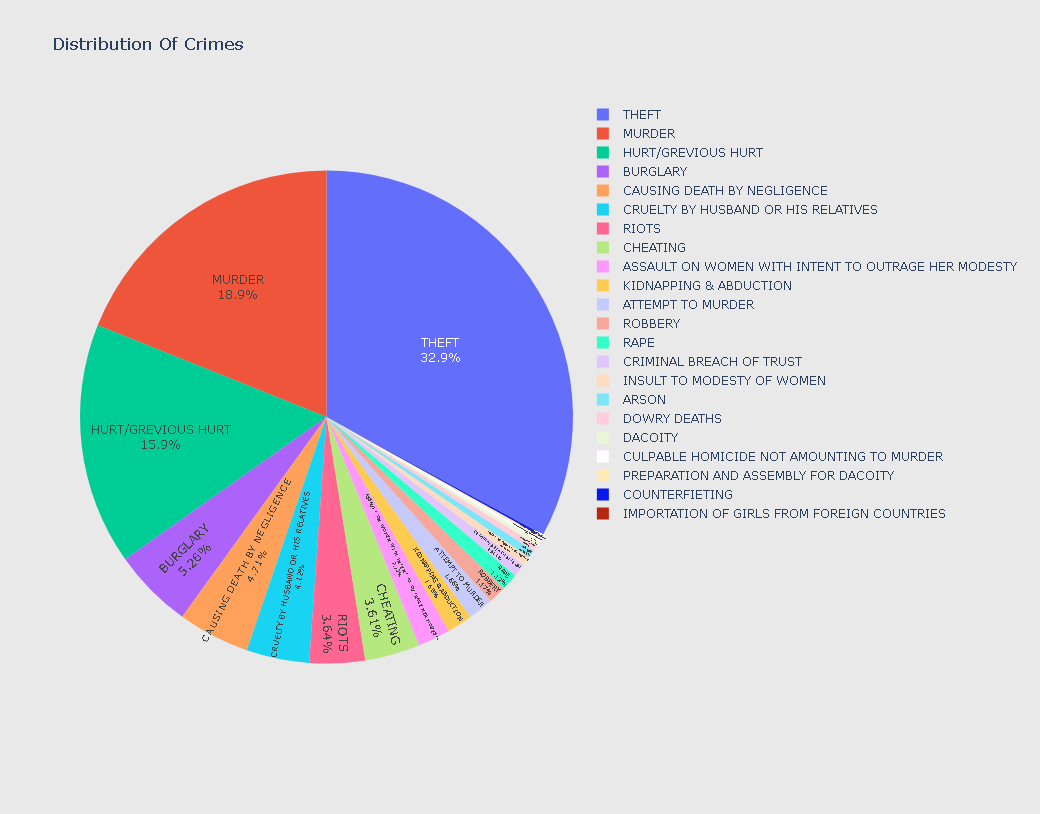

In [20]:
values = 8050869, 703954, 89228, 478274, 713714, 118818, 63882, 496534, 2234678, 7001060, 1549854, 368042, 1535194, 53436, 227408, 6743752, 182404, 906310, 248108, 1750402, 1784, 2003728, 7001060
fig = go.Figure(data=[go.Pie(labels=labels, values=values, textinfo='label+percent', textposition='inside')])

fig.update_layout(
    uniformtext_minsize= 20,
    title_text="Distribution Of Crimes",
    paper_bgcolor='rgb(233,233,233)',
    autosize=False,
    width=1150,
    height=800)
fig.show()

In [21]:
labels = ['MURDER', 'KIDNAPPING & ABDUCTION', 'BURGLARY', 'RIOTS', 'CHEATING',
          'HURT/GREVIOUS HURT', 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY', 
          'CRUELTY BY HUSBAND OR HIS RELATIVES', 'CAUSING DEATH BY NEGLIGENCE','THEFT'] 

values = [df[col].sum() for col in labels]
print(values)

[np.int64(805086), np.int64(713714), np.int64(2234678), np.int64(1549854), np.int64(1535194), np.int64(6743752), np.int64(906310), np.int64(1750402), np.int64(2003728), np.int64(7001060)]


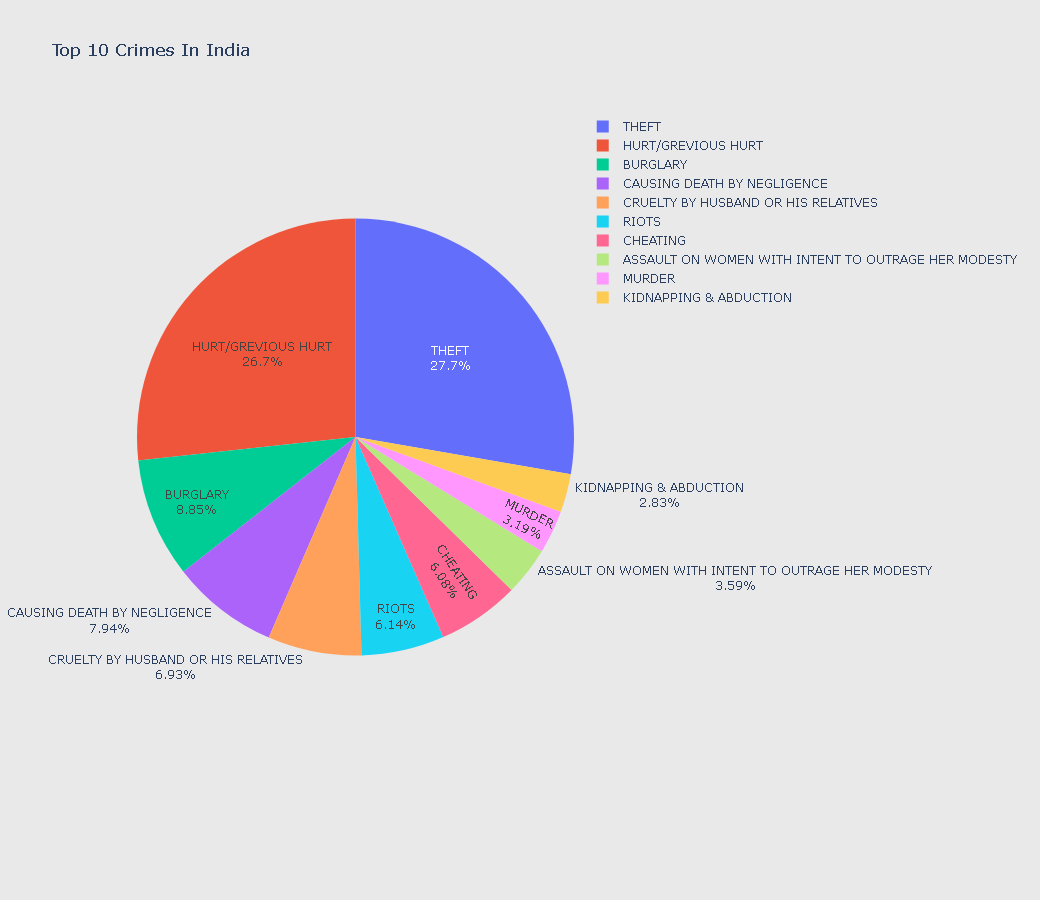

In [22]:
values = 805086, 713714, 2234678, 1549854, 1535194, 6743752, 906310, 1750402, 2003728, 7001060
fig = go.Figure(data=[go.Pie(labels=labels, values=values, textinfo='label+percent')])

fig.update_layout(
    uniformtext_minsize= 20,
    title_text="Top 10 Crimes In India",
    paper_bgcolor='rgb(233,233,233)',
    autosize=False,
    width=1000,
    height=900)
fig.show()

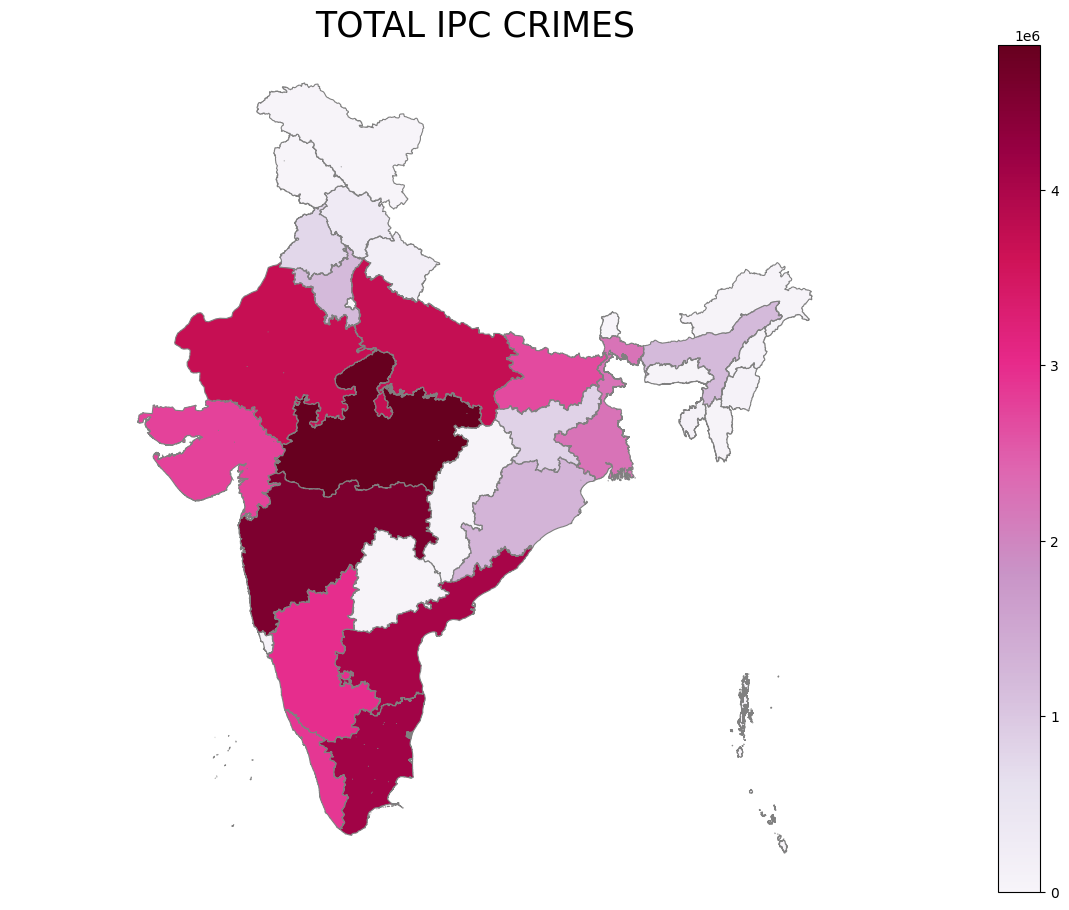

In [23]:
fig, ax = plt.subplots(1, figsize=(15, 11))
ax.axis('off')
ax.set_title('TOTAL IPC CRIMES', fontdict={'fontsize': '25', 'fontweight' : '3'})

# plot the figure
merged_Ind.dropna().plot(column='TOTAL IPC CRIMES', cmap='PuRd',linewidth=0.8, ax=ax, edgecolor='grey')
norm = Normalize(vmin=merged_Ind['TOTAL IPC CRIMES'].min(), vmax= merged_Ind["TOTAL IPC CRIMES"].max())
n_cmap = cm.ScalarMappable(norm=norm, cmap='PuRd')
n_cmap.set_array([])
fig.colorbar(n_cmap, ax=ax)
ax.set_axis_off()
plt.axis('equal')
plt.show()

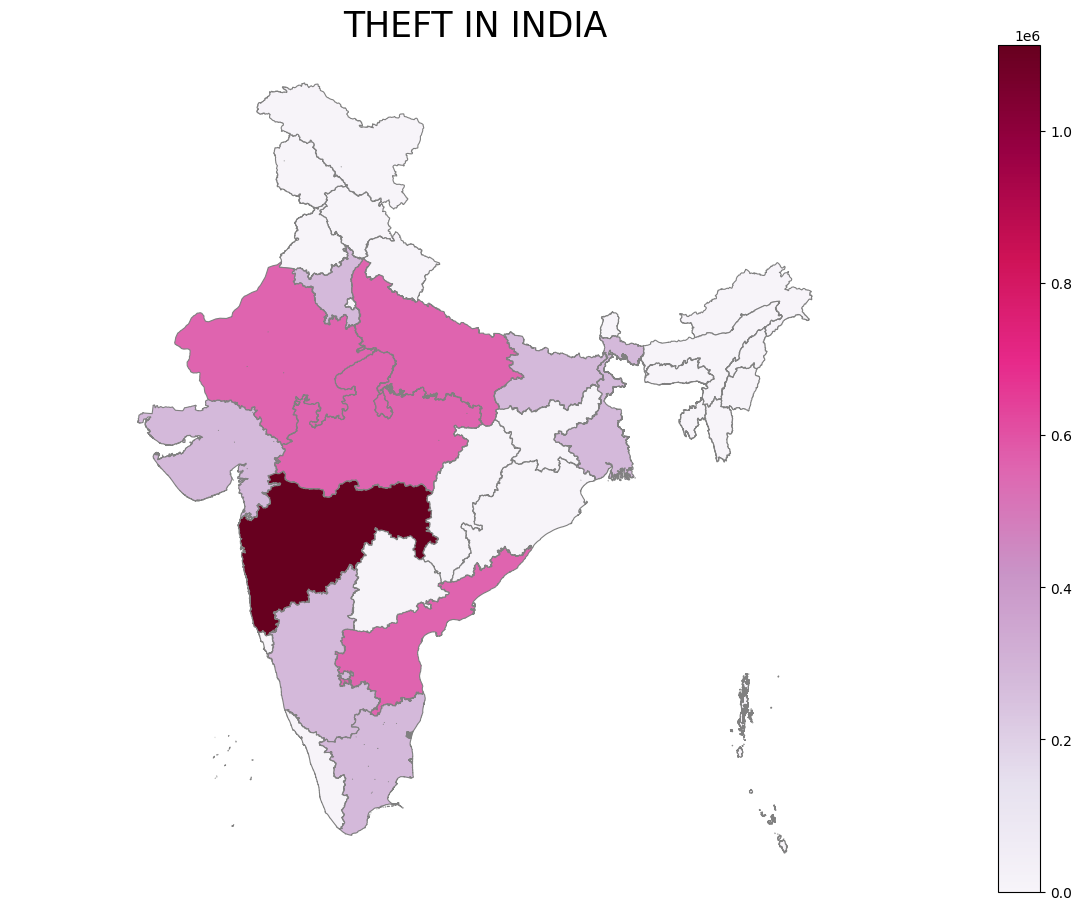

In [24]:
fig, ax = plt.subplots(1, figsize=(15, 11))
ax.axis('off')
ax.set_title('THEFT IN INDIA', fontdict={'fontsize': '25', 'fontweight' : '3'})

# plot the figure
merged_Ind.dropna().plot(column='THEFT', cmap='PuRd', figsize=fig, scheme='equal_interval',linewidth=0.8, ax=ax, edgecolor='grey')
norm = Normalize(vmin=merged_Ind['THEFT'].min(), vmax= merged_Ind["THEFT"].max())
n_cmap = cm.ScalarMappable(norm=norm, cmap='PuRd')
n_cmap.set_array([])
fig.colorbar(n_cmap, ax=ax)
ax.set_axis_off()
plt.axis('equal')
plt.show()

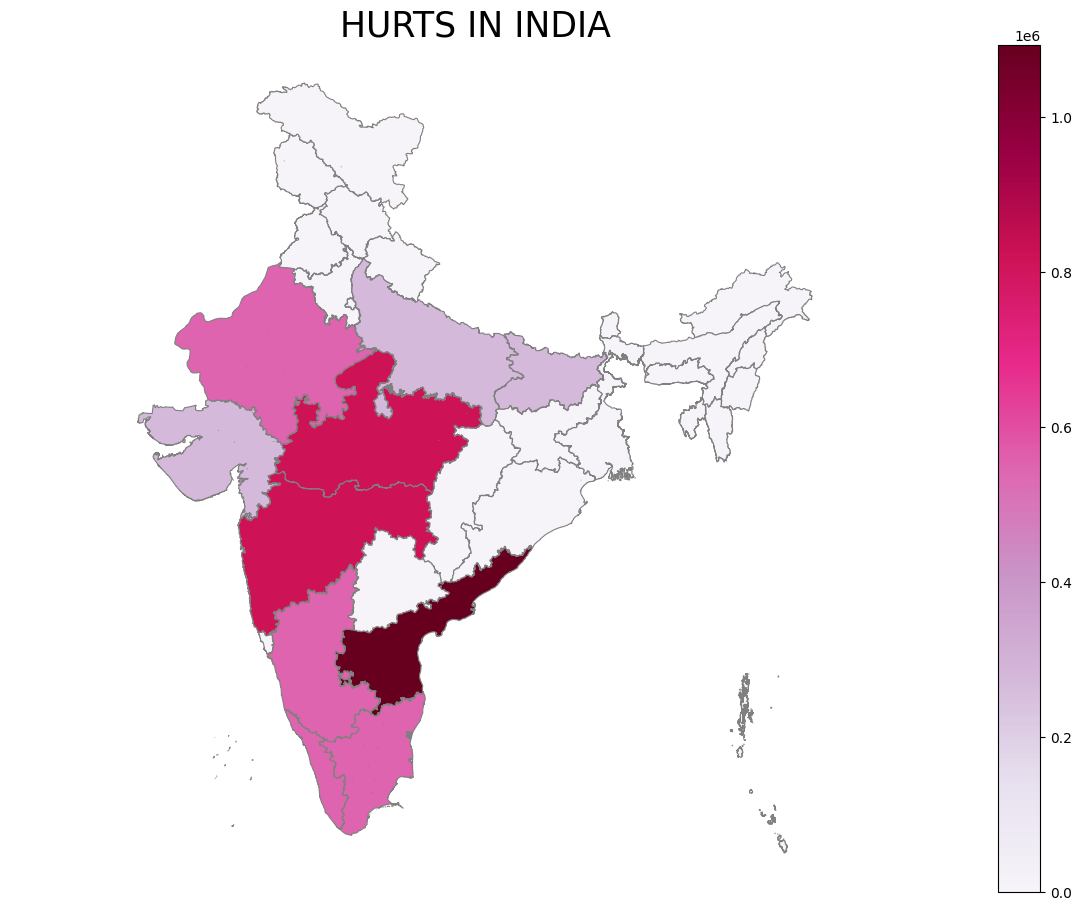

In [25]:
fig, ax = plt.subplots(1, figsize=(15, 11))
ax.axis('off')
ax.set_title('HURTS IN INDIA', fontdict={'fontsize': '25', 'fontweight' : '3'})

# plot the figure
merged_Ind.dropna().plot(column='HURT/GREVIOUS HURT', cmap='PuRd', figsize=fig, scheme='equal_interval',linewidth=0.8, ax=ax, edgecolor='grey')
norm = Normalize(vmin=merged_Ind['HURT/GREVIOUS HURT'].min(), vmax= merged_Ind["HURT/GREVIOUS HURT"].max())
n_cmap = cm.ScalarMappable(norm=norm, cmap='PuRd')
n_cmap.set_array([])
fig.colorbar(n_cmap, ax=ax)
ax.set_axis_off()
plt.axis('equal')
plt.show()

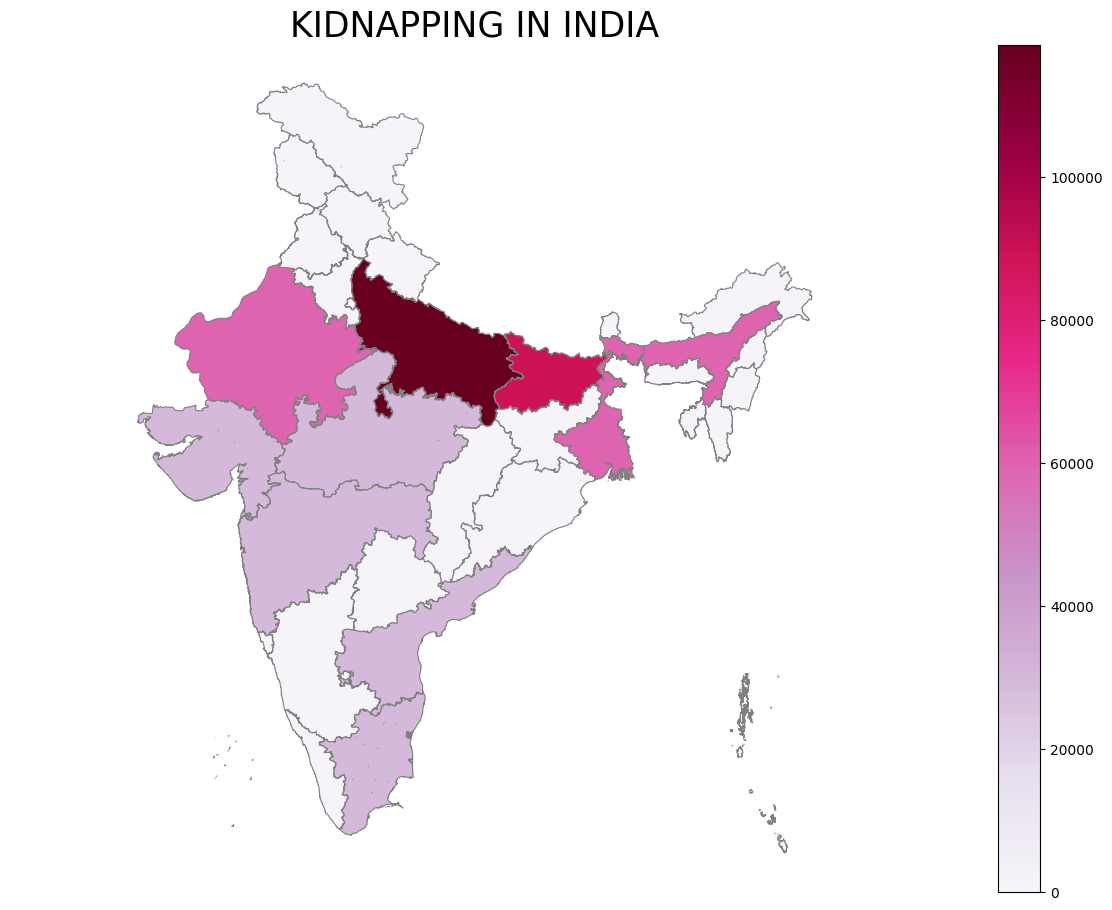

In [26]:
fig, ax = plt.subplots(1, figsize=(15, 11))
ax.axis('off')
ax.set_title('KIDNAPPING IN INDIA', fontdict={'fontsize': '25', 'fontweight' : '3'})

# plot the figure
merged_Ind.dropna().plot(column='KIDNAPPING & ABDUCTION', cmap='PuRd', figsize=fig, scheme='equal_interval',linewidth=0.8, ax=ax, edgecolor='grey')
norm = Normalize(vmin=merged_Ind['KIDNAPPING & ABDUCTION'].min(), vmax= merged_Ind["KIDNAPPING & ABDUCTION"].max())
n_cmap = cm.ScalarMappable(norm=norm, cmap='PuRd')
n_cmap.set_array([])
fig.colorbar(n_cmap, ax=ax)
ax.set_axis_off()
plt.axis('equal')
plt.show()

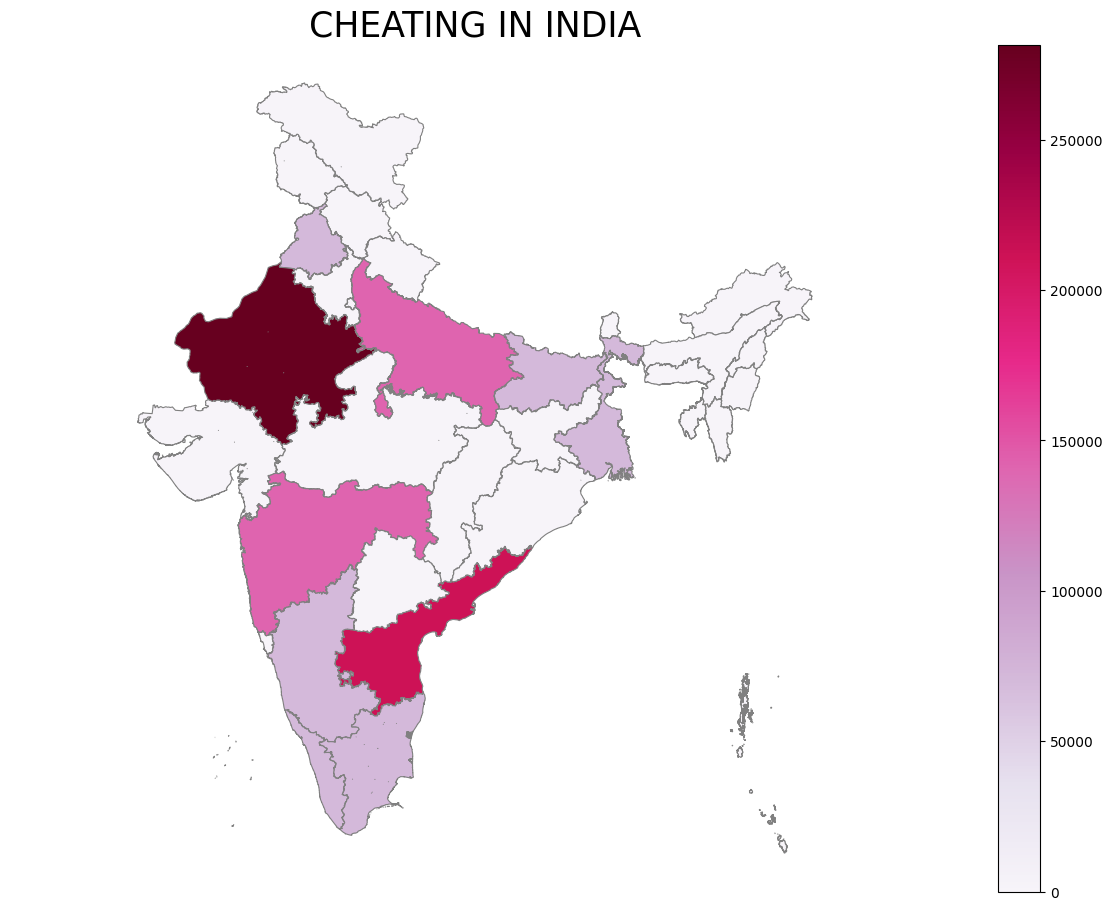

In [27]:
fig, ax = plt.subplots(1, figsize=(15, 11))
ax.axis('off')
ax.set_title('CHEATING IN INDIA', fontdict={'fontsize': '25', 'fontweight' : '3'})

# plot the figure
merged_Ind.dropna().plot(column='CHEATING', cmap='PuRd', figsize=fig, scheme='equal_interval',linewidth=0.8, ax=ax, edgecolor='grey')
norm = Normalize(vmin=merged_Ind['CHEATING'].min(), vmax= merged_Ind["CHEATING"].max())
n_cmap = cm.ScalarMappable(norm=norm, cmap='PuRd')
n_cmap.set_array([])
fig.colorbar(n_cmap, ax=ax)
ax.set_axis_off()
plt.axis('equal')
plt.show()

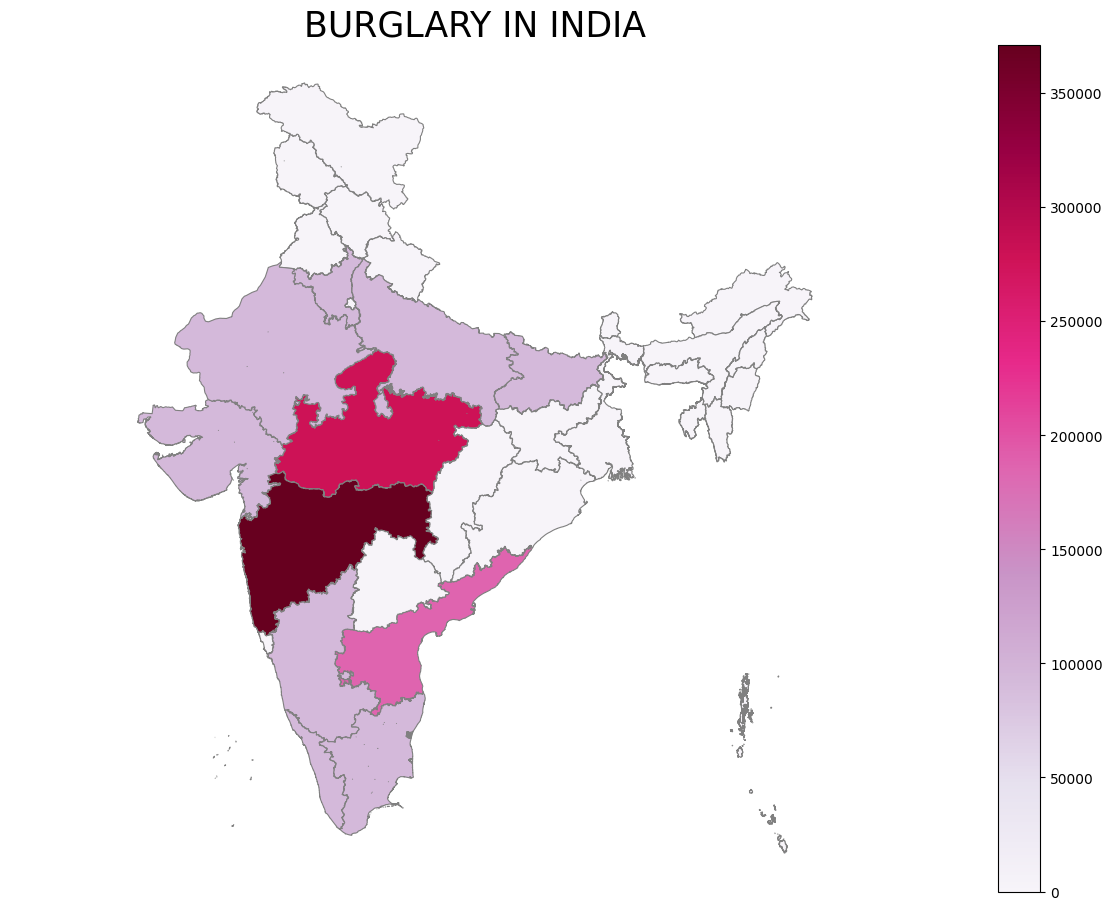

In [28]:
fig, ax = plt.subplots(1, figsize=(15, 11))
ax.axis('off')
ax.set_title('BURGLARY IN INDIA', fontdict={'fontsize': '25', 'fontweight' : '3'})

# plot the figure
merged_Ind.dropna().plot(column='BURGLARY', cmap='PuRd', figsize=fig, scheme='equal_interval',linewidth=0.8, ax=ax, edgecolor='grey')
norm = Normalize(vmin=merged_Ind['BURGLARY'].min(), vmax= merged_Ind["BURGLARY"].max())
n_cmap = cm.ScalarMappable(norm=norm, cmap='PuRd')
n_cmap.set_array([])
fig.colorbar(n_cmap, ax=ax)
ax.set_axis_off()
plt.axis('equal')
plt.show()

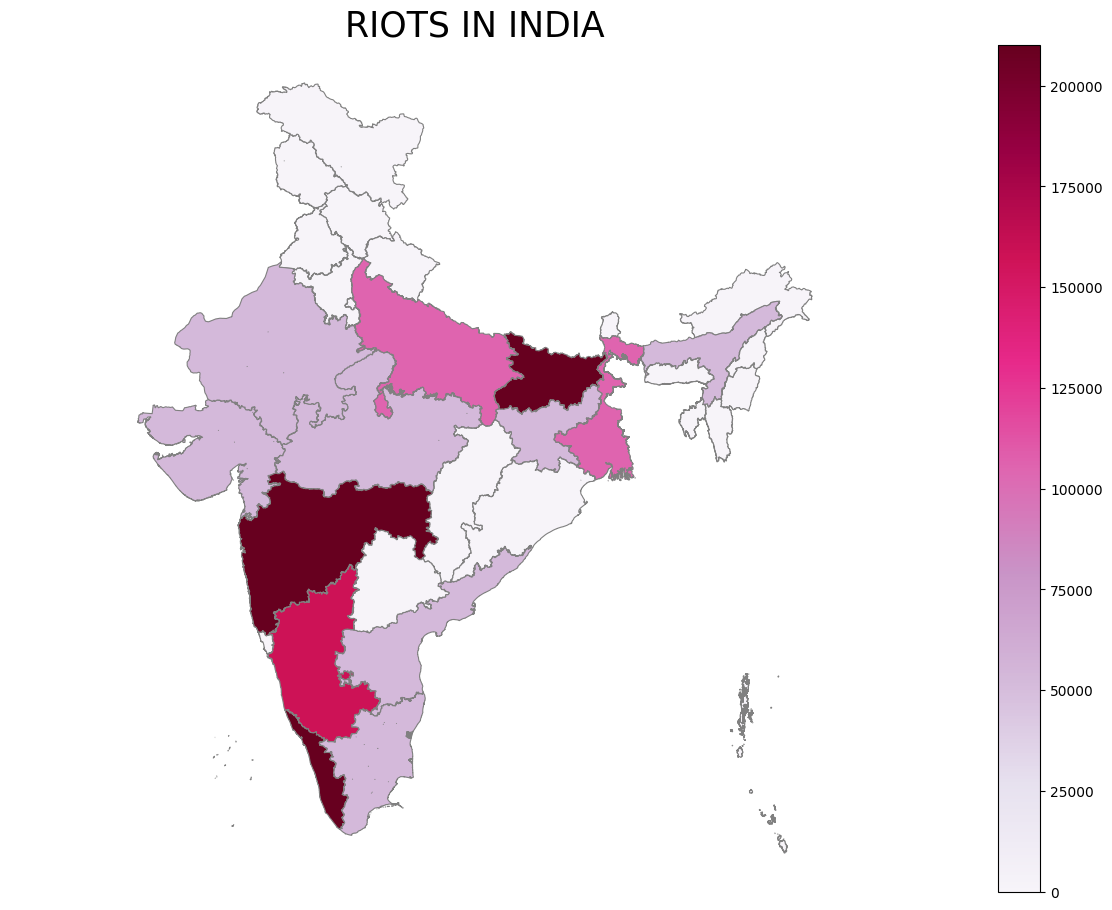

In [29]:
fig, ax = plt.subplots(1, figsize=(15, 11))
ax.axis('off')
ax.set_title('RIOTS IN INDIA', fontdict={'fontsize': '25', 'fontweight' : '3'})

# plot the figure
merged_Ind.dropna().plot(column='RIOTS', cmap='PuRd', figsize=fig, scheme='equal_interval',linewidth=0.8, ax=ax, edgecolor='grey')
norm = Normalize(vmin=merged_Ind['RIOTS'].min(), vmax= merged_Ind["RIOTS"].max())
n_cmap = cm.ScalarMappable(norm=norm, cmap='PuRd')
n_cmap.set_array([])
fig.colorbar(n_cmap, ax=ax)
ax.set_axis_off()
plt.axis('equal')
plt.show()

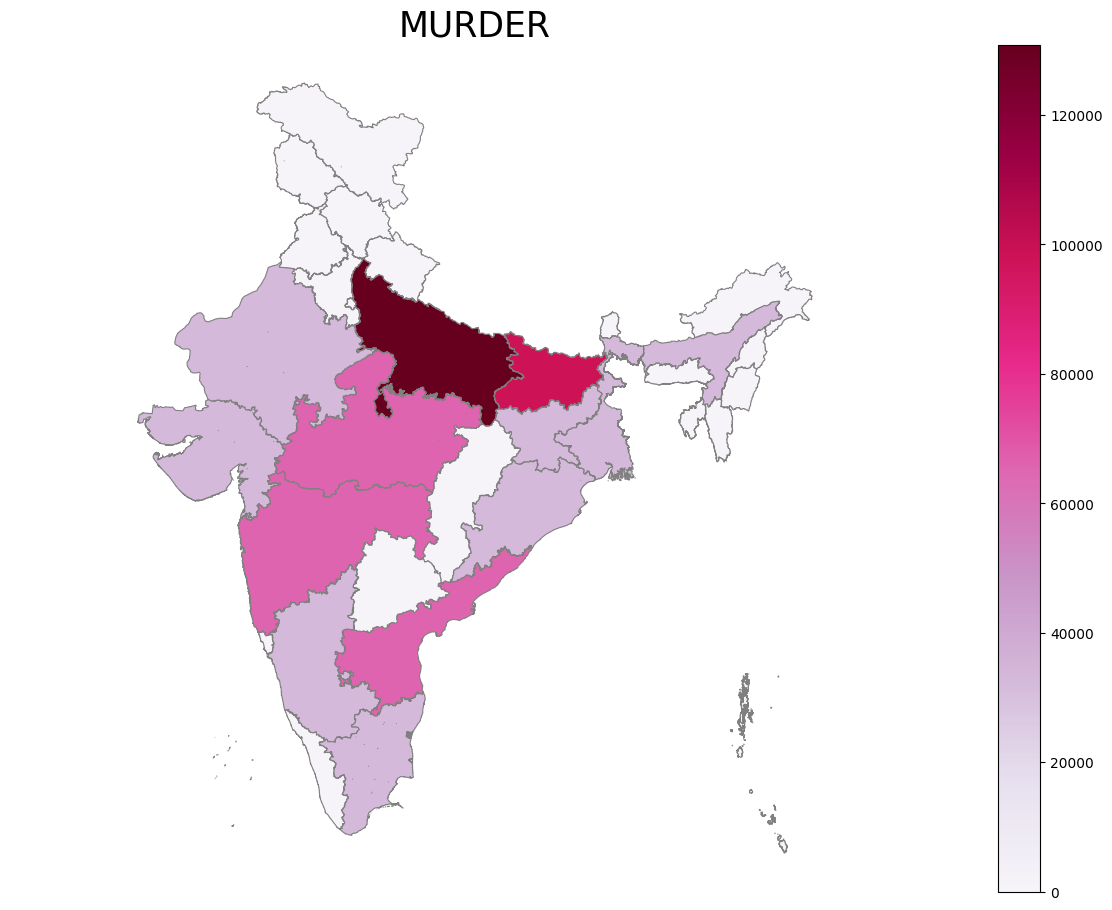

In [30]:
fig, ax = plt.subplots(1, figsize=(15, 11))
ax.axis('off')
ax.set_title('MURDER', fontdict={'fontsize': '25', 'fontweight' : '3'})

# plot the figure
merged_Ind.dropna().plot(column='MURDER', cmap='PuRd', figsize=fig, scheme='equal_interval',linewidth=0.8, ax=ax, edgecolor='grey')
norm = Normalize(vmin=merged_Ind['MURDER'].min(), vmax= merged_Ind["MURDER"].max())
n_cmap = cm.ScalarMappable(norm=norm, cmap='PuRd')
n_cmap.set_array([])
fig.colorbar(n_cmap, ax=ax)
ax.set_axis_off()
plt.axis('equal')
plt.show()

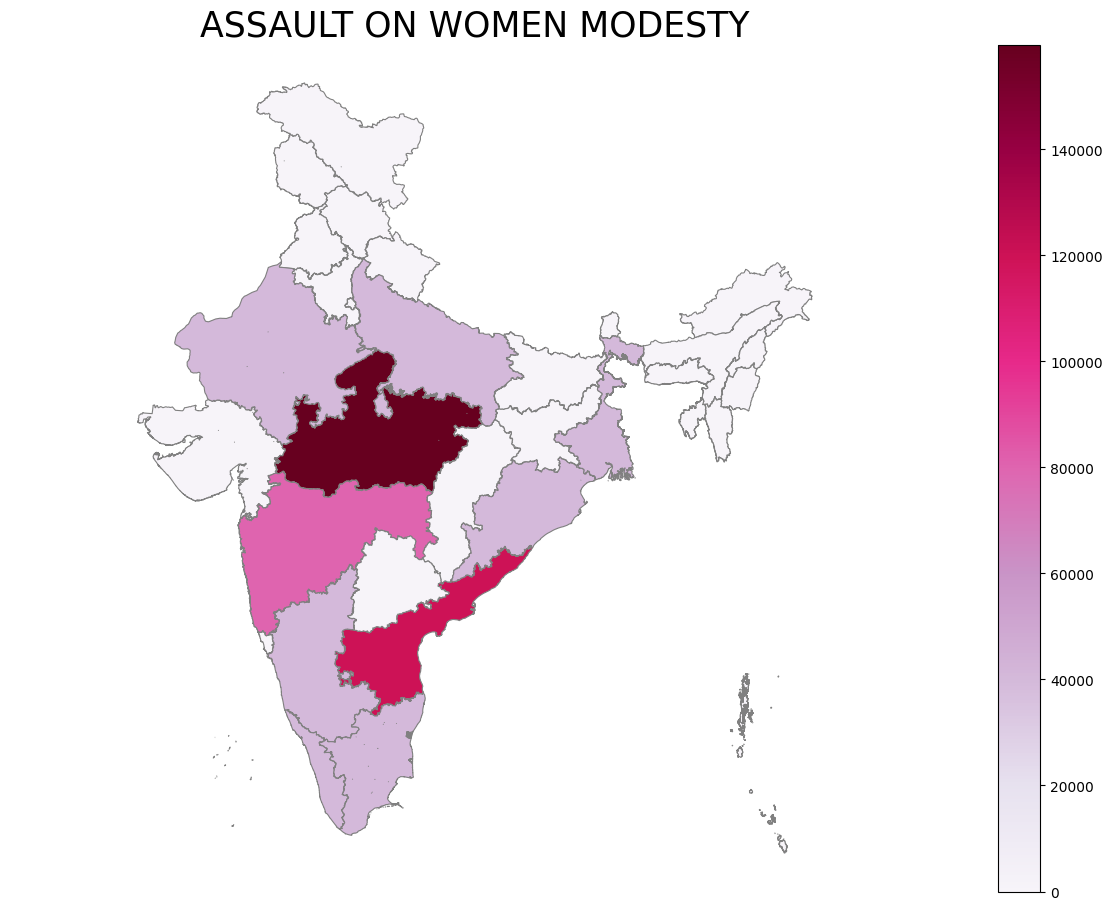

In [31]:
fig, ax = plt.subplots(1, figsize=(15, 11))
ax.axis('off')
ax.set_title('ASSAULT ON WOMEN MODESTY', fontdict={'fontsize': '25', 'fontweight' : '3'})

# plot the figure
merged_Ind.dropna().plot(column='ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY', cmap='PuRd', figsize=fig, scheme='equal_interval',linewidth=0.8, ax=ax, edgecolor='grey')
norm = Normalize(vmin=merged_Ind['ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY'].min(), vmax= merged_Ind["ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY"].max())
n_cmap = cm.ScalarMappable(norm=norm, cmap='PuRd')
n_cmap.set_array([])
fig.colorbar(n_cmap, ax=ax)
ax.set_axis_off()
plt.axis('equal')
plt.show()

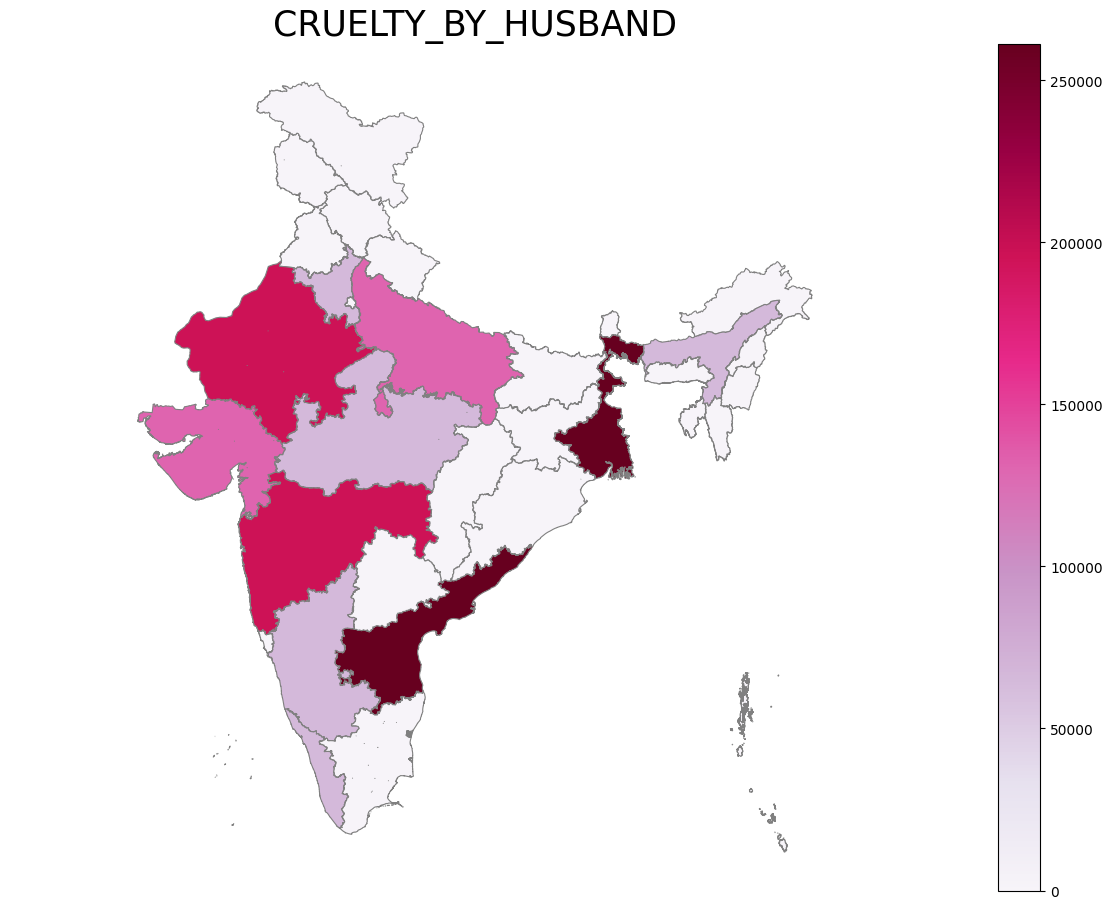

In [32]:
fig, ax = plt.subplots(1, figsize=(15, 11))
ax.axis('off')
ax.set_title('CRUELTY_BY_HUSBAND', fontdict={'fontsize': '25', 'fontweight' : '3'})

# plot the figure
merged_Ind.dropna().plot(column='CRUELTY BY HUSBAND OR HIS RELATIVES', cmap='PuRd', figsize=fig, scheme='equal_interval',linewidth=0.8, ax=ax, edgecolor='grey')
norm = Normalize(vmin=merged_Ind['CRUELTY BY HUSBAND OR HIS RELATIVES'].min(), vmax= merged_Ind["CRUELTY BY HUSBAND OR HIS RELATIVES"].max())
n_cmap = cm.ScalarMappable(norm=norm, cmap='PuRd')
n_cmap.set_array([])
fig.colorbar(n_cmap, ax=ax)
ax.set_axis_off()
plt.axis('equal')
plt.show()

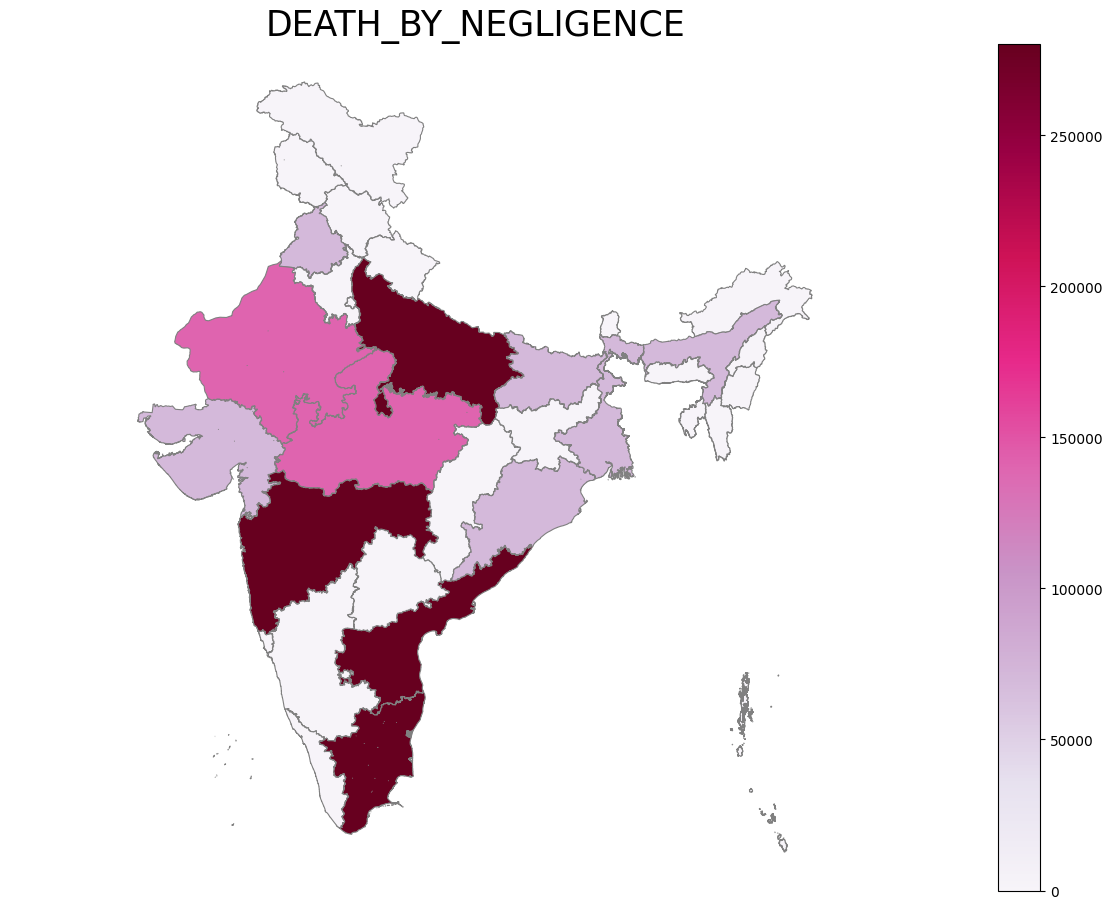

In [33]:
fig, ax = plt.subplots(1, figsize=(15, 11))
ax.axis('off')
ax.set_title('DEATH_BY_NEGLIGENCE', fontdict={'fontsize': '25', 'fontweight' : '3'})

# plot the figure
merged_Ind.dropna().plot(column='CAUSING DEATH BY NEGLIGENCE', cmap='PuRd', figsize=fig, scheme='equal_interval',linewidth=0.8, ax=ax, edgecolor='grey')
norm = Normalize(vmin=merged_Ind['CAUSING DEATH BY NEGLIGENCE'].min(), vmax= merged_Ind["CAUSING DEATH BY NEGLIGENCE"].max())
n_cmap = cm.ScalarMappable(norm=norm, cmap='PuRd')
n_cmap.set_array([])
fig.colorbar(n_cmap, ax=ax)
ax.set_axis_off()
plt.axis('equal')
plt.show()

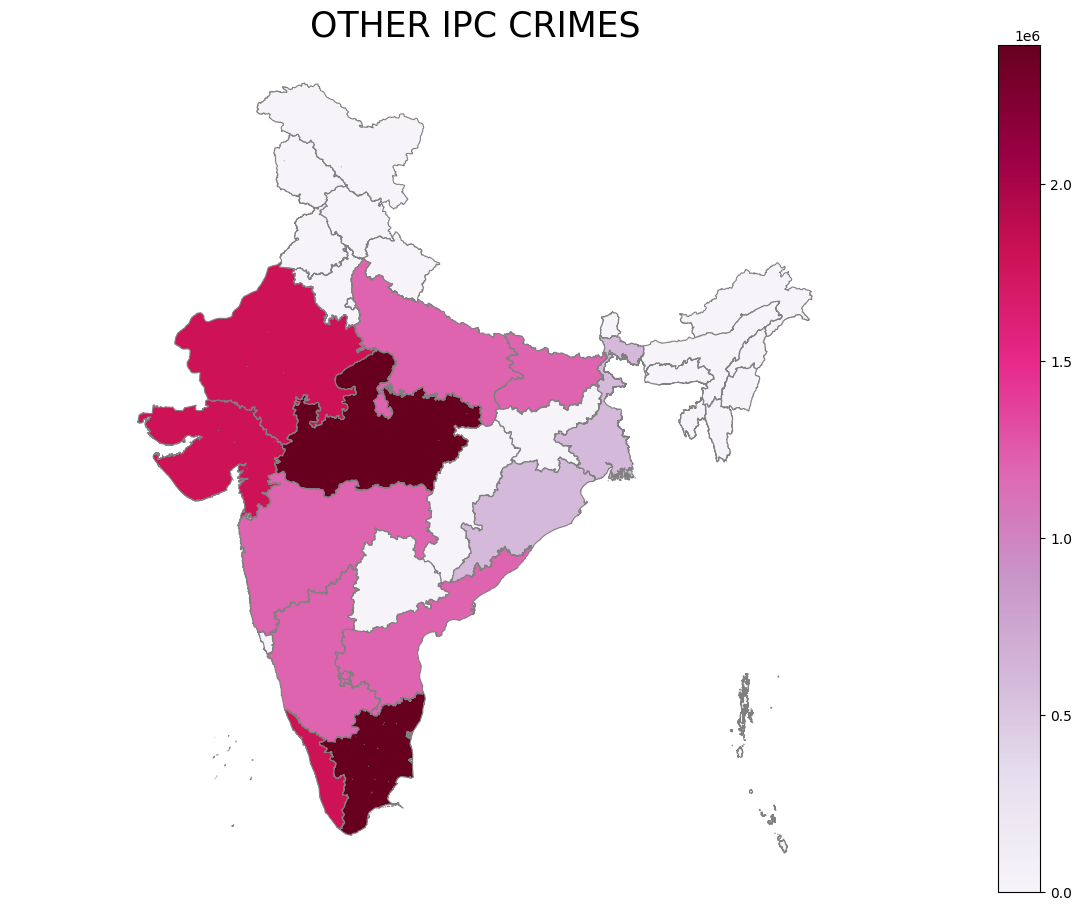

In [34]:
fig, ax = plt.subplots(1, figsize=(15, 11))
ax.axis('off')
ax.set_title('OTHER IPC CRIMES', fontdict={'fontsize': '25', 'fontweight' : '3'})

# plot the figure
merged_Ind.dropna().plot(column='OTHER IPC CRIMES', cmap='PuRd', figsize=fig, scheme='equal_interval',linewidth=0.8, ax=ax, edgecolor='grey')
norm = Normalize(vmin=merged_Ind['OTHER IPC CRIMES'].min(), vmax= merged_Ind["OTHER IPC CRIMES"].max())
n_cmap = cm.ScalarMappable(norm=norm, cmap='PuRd')
n_cmap.set_array([])
fig.colorbar(n_cmap, ax=ax)
ax.set_axis_off()
plt.axis('equal')
plt.show()

In [35]:
crimes_total = df.groupby(['STATE/UT', "YEAR"]).agg({"TOTAL IPC CRIMES": sum }).reset_index()

In [36]:
crimes_total

,STATE/UT,YEAR,TOTAL IPC CRIMES
0,A & N ISLANDS,2001,1316
1,A & N ISLANDS,2002,1216
2,A & N ISLANDS,2003,1288
3,A & N ISLANDS,2004,1496
4,A & N ISLANDS,2005,1364
...,...,...,...
415,WEST BENGAL,2008,210838
416,WEST BENGAL,2009,226072
417,WEST BENGAL,2010,259232
418,WEST BENGAL,2011,286394


In [37]:
total_crime_yearwise = df.groupby(["YEAR"]).agg({"TOTAL IPC CRIMES": sum }).reset_index()
total_crime_yearwise

,YEAR,TOTAL IPC CRIMES
0,2001,3538616
1,2002,3560660
2,2003,3432240
3,2004,3664020
4,2005,3645204
5,2006,3756586
6,2007,3979346
7,2008,4186758
8,2009,4242690
9,2010,4449662


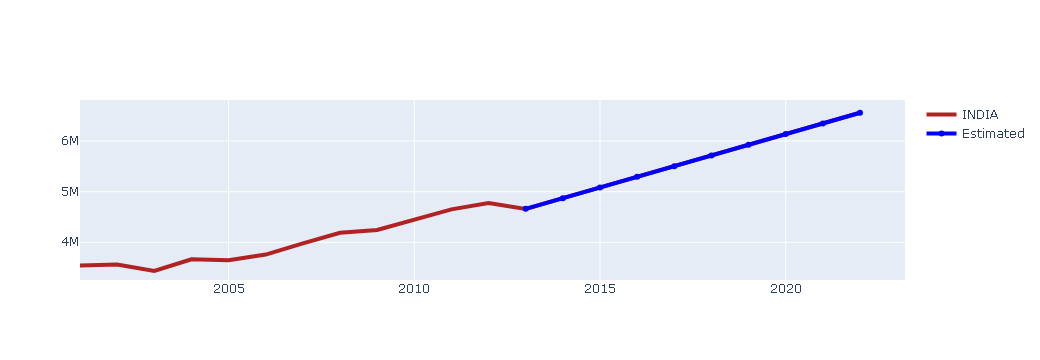

In [38]:
an_arim = ARIMA(total_crime_yearwise['TOTAL IPC CRIMES'][:10].astype(np.float64).to_numpy(), order=(1,2,0))
an_model = an_arim.fit()
def get_mape(actual, predicted):
    y_actual = np.array(actual)
    y_pred = np.array(predicted)
    return np.round(np.mean(np.abs((y_actual - y_pred)/actual)) * 100,2)
forecast_an = an_model.predict(10,11)
forecast_an
forecast_an_df = an_model.forecast(steps=10)
forecast_an_df
get_mape(total_crime_yearwise['TOTAL IPC CRIMES'][10:12],forecast_an)
i=12
for j in range(len(forecast_an_df)):
    total_crime_yearwise.loc[i] = total_crime_yearwise.YEAR[i-1]+1
    total_crime_yearwise.loc[i,'TOTAL IPC CRIMES'] = int(forecast_an_df[j])
    i = i+1
fig = go.Figure()
fig.add_trace(go.Scatter(x= total_crime_yearwise["YEAR"], y= total_crime_yearwise['TOTAL IPC CRIMES'],
                    name = "INDIA",line=dict(color='firebrick', width=4)))
fig.add_trace(go.Scatter(x= total_crime_yearwise["YEAR"][12:], y= total_crime_yearwise['TOTAL IPC CRIMES'][12:],
                    name = "Estimated",line=dict(color='blue', width=4)))

In [39]:
def adfull(ts):
    result = adfuller(ts, autolag=None)
    result_out = pd.Series(result[0:4], index=["Test Stats",
                                              'P-value',
                                              'lags_used',
                                              'Number of observation'])
    print(result_out)
    

In [40]:
#Crimes Trend in Andaman 
crime_AN_df = crimes_total[crimes_total['STATE/UT'] == "A & N ISLANDS"]
#ts_decompose = sm.tsa.seasonal_decompose(np.array(crime_AN_df['TOTAL']),
#                                 model = "multiplicative", period=2)
#ts_plot = ts_decompose.plot()
crime_AN_df

,STATE/UT,YEAR,TOTAL IPC CRIMES
0,A & N ISLANDS,2001,1316
1,A & N ISLANDS,2002,1216
2,A & N ISLANDS,2003,1288
3,A & N ISLANDS,2004,1496
4,A & N ISLANDS,2005,1364
5,A & N ISLANDS,2006,1352
6,A & N ISLANDS,2007,1614
7,A & N ISLANDS,2008,1764
8,A & N ISLANDS,2009,1882
9,A & N ISLANDS,2010,1960


In [41]:
crime_AN_forecast = crime_AN_df.copy()
crime_AN_forecast.drop('STATE/UT', axis = 1, inplace = True)

In [42]:
crime_AN_forecast

,YEAR,TOTAL IPC CRIMES
0,2001,1316
1,2002,1216
2,2003,1288
3,2004,1496
4,2005,1364
5,2006,1352
6,2007,1614
7,2008,1764
8,2009,1882
9,2010,1960


In [43]:
adfull(crime_AN_forecast['TOTAL IPC CRIMES'])

Test Stats               0.777940
P-value                  0.991272
lags_used                4.000000
Number of observation    7.000000
dtype: float64


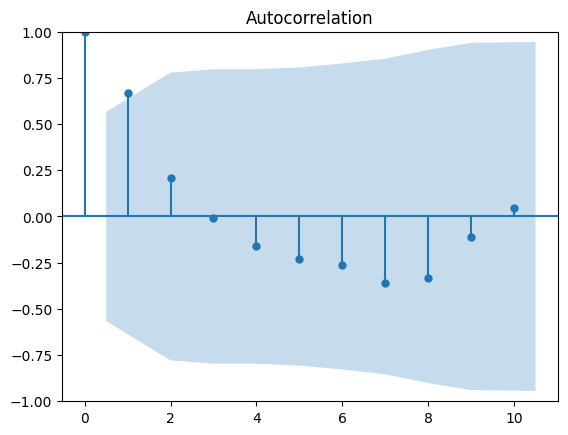

In [44]:
acf_plot = plot_acf(crime_AN_forecast['TOTAL IPC CRIMES'], lags = 10)

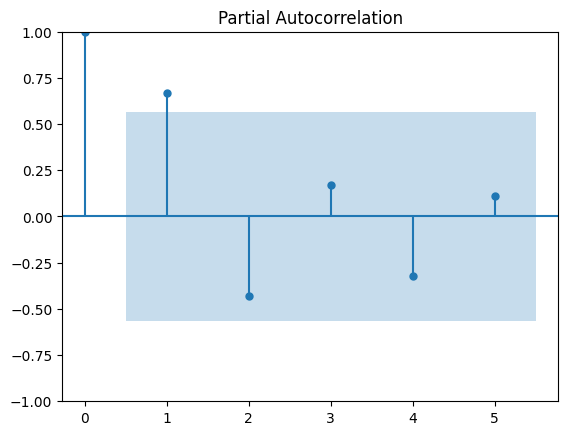

In [45]:
pcf_1 = plot_pacf(crime_AN_forecast['TOTAL IPC CRIMES'], lags = 5, method='ywm')

In [46]:
an_arim = ARIMA(crime_AN_forecast['TOTAL IPC CRIMES'][:10].astype(np.float64).to_numpy(), order=(1,0,0))
an_model = an_arim.fit()
#print(an_model.summary())

In [47]:
def get_mape(actual, predicted):
    y_actual = np.array(actual)
    y_pred = np.array(predicted)
    return np.round(np.mean(np.abs((y_actual - y_pred)/actual)) * 100,2)

In [48]:
forecast_an = an_model.predict(10,11)
forecast_an

array([1912.57605573, 1871.23359068])

In [49]:
forecast_an_df = an_model.forecast(steps=10)
forecast_an_df

array([1912.57605573, 1871.23359068, 1835.19273742, 1803.77363597,
       1776.38360919, 1752.50598276, 1731.69033887, 1713.54401967,
       1697.7247204 , 1683.93403223])

In [50]:
get_mape(crime_AN_forecast['TOTAL IPC CRIMES'][10:12],forecast_an)

np.float64(28.79)

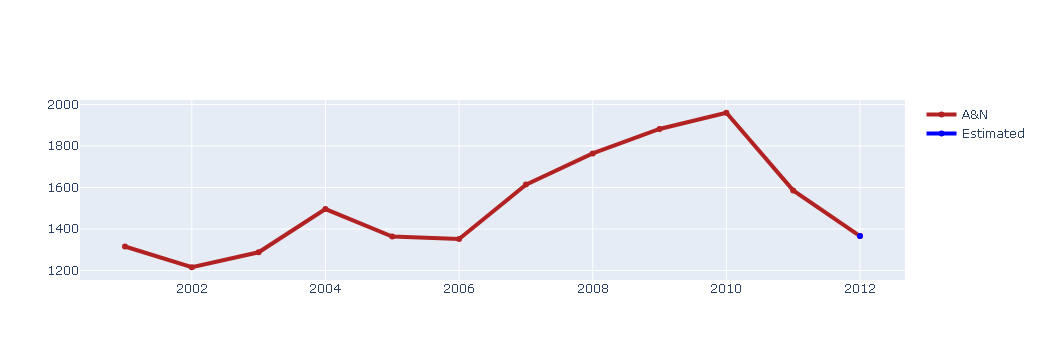

In [51]:
fig = go.Figure()
fig.add_trace(go.Scatter(x= crime_AN_df["YEAR"], y= crime_AN_df['TOTAL IPC CRIMES'],
                    name = "A&N",line=dict(color='firebrick', width=4)))
fig.add_trace(go.Scatter(x= crime_AN_forecast["YEAR"][11:], y= crime_AN_forecast['TOTAL IPC CRIMES'][11:],
                    name = "Estimated",line=dict(color='blue', width=4)))

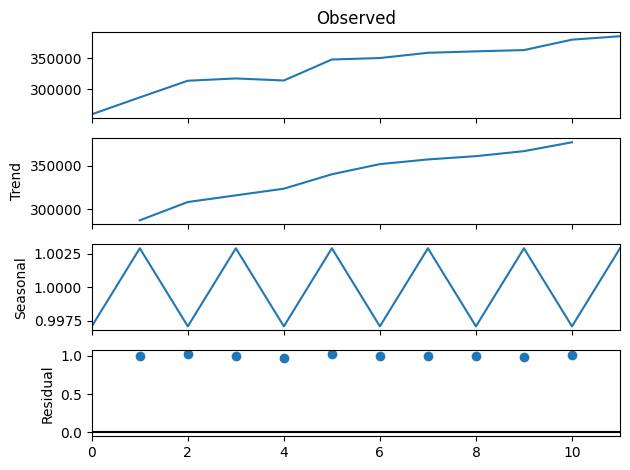

In [52]:
#trend in Andhra Pradesh
crime_AP_df = crimes_total[crimes_total['STATE/UT'] == "ANDHRA PRADESH"]
ts_decompose = sm.tsa.seasonal_decompose(np.array(crime_AP_df['TOTAL IPC CRIMES']),
                                 model = "multiplicative", period=2)
ts_plot = ts_decompose.plot()

In [53]:
crimes_AP_forecast = crime_AP_df.copy()
crimes_AP_forecast.drop(['STATE/UT'], axis = 1, inplace = True)

In [54]:
crimes_AP_forecast = crimes_AP_forecast.reset_index(drop = True)
crimes_AP_forecast

,YEAR,TOTAL IPC CRIMES
0,2001,260178
1,2002,287220
2,2003,313902
3,2004,317512
4,2005,314246
5,2006,347818
6,2007,350174
7,2008,358550
8,2009,360882
9,2010,362876


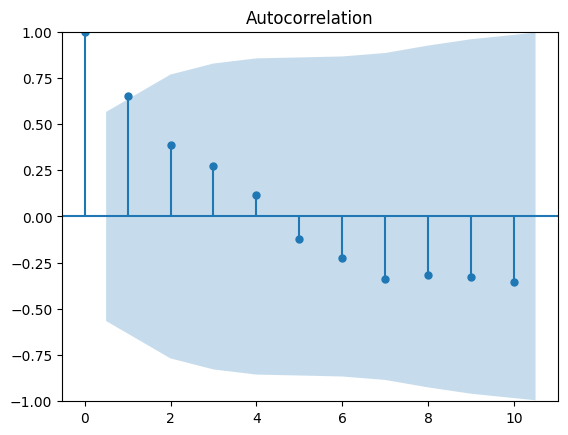

In [55]:
acf_plot = plot_acf(crimes_AP_forecast['TOTAL IPC CRIMES'], lags = 10)

In [56]:
ap_arim = ARIMA(crimes_AP_forecast['TOTAL IPC CRIMES'][:10].astype(np.float64).to_numpy(), order=(1,2,0))
ap_model = ap_arim.fit()
ap_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   10
Model:                 ARIMA(1, 2, 0)   Log Likelihood                 -90.289
Date:                Sat, 16 May 2026   AIC                            184.579
Time:                        14:29:24   BIC                            184.738
Sample:                             0   HQIC                           183.507
                                 - 10                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0243      0.179     -0.136      0.892      -0.375       0.326
sigma2      3.244e+08    1.1e-10   2.96e+18      0.000    3.24e+08    3.24e+08
===================================================================================
Ljung-Box (L1) (Q):                   2.70   Jarque-Bera (JB):                 0.87
Prob(Q):                              0.10   Prob(JB):                         0.65
Heteroskedasticity (H):               0.10   Skew:                             0.79
Prob(H) (two-sided):                  0.09   Kurtosis:                         3.34
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number    inf. Standard errors may be unstable.
"""

In [57]:
forecast_ap = ap_model.predict(10,11)
forecast_ap
#crimes_AP_forecast.TOTAL[10:13]

array([364878.20141282, 366880.20382218])

In [58]:
get_mape(crimes_AP_forecast['TOTAL IPC CRIMES'][10:12],forecast_ap)

np.float64(4.29)

In [59]:
forecast_df = ap_model.forecast(steps=10)
forecast_df

array([364878.20141282, 366880.20382218, 368882.21106026, 370884.21818117,
       372886.22530493, 374888.23242861, 376890.2395523 , 378892.24667599,
       380894.25379968, 382896.26092337])

In [60]:
i=12
for j in range(len(forecast_df)):
   crimes_AP_forecast.loc[i, 'YEAR'] = crimes_AP_forecast.loc[i-1, 'YEAR'] + 1
   crimes_AP_forecast.loc[i, 'TOTAL IPC CRIMES'] = int(forecast_df[j])
   i = i+1

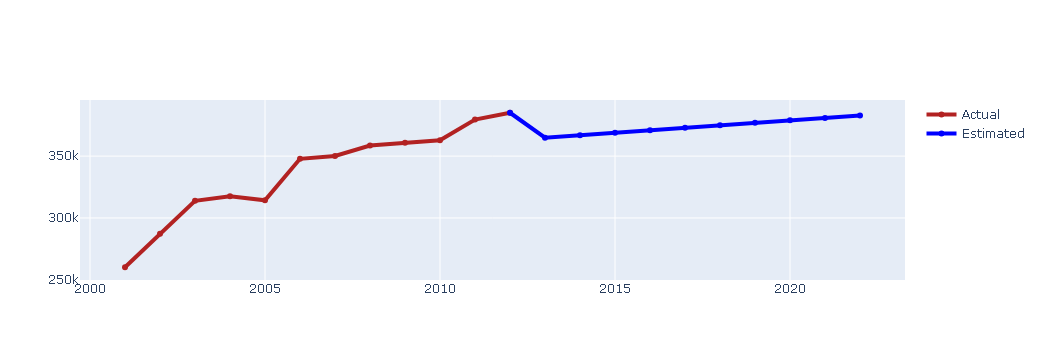

In [61]:
fig = go.Figure()
fig.add_trace(go.Scatter(x= crime_AP_df['YEAR'], y= crime_AP_df['TOTAL IPC CRIMES'],
                    name = "Actual",line=dict(color='firebrick', width=4)))
fig.add_trace(go.Scatter(x= crimes_AP_forecast["YEAR"][11:], y= crimes_AP_forecast['TOTAL IPC CRIMES'][11:],
                    name = "Estimated",line=dict(color='blue', width=4)))


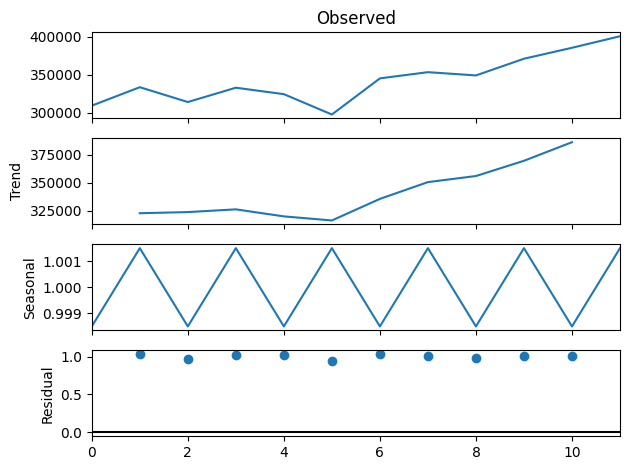

In [62]:
crime_TN_df = crimes_total[crimes_total['STATE/UT']=='TAMIL NADU']
ts_decompose = sm.tsa.seasonal_decompose(np.array(crime_TN_df['TOTAL IPC CRIMES']),
                                 model = "multiplicative", period=2)
ts_plot = ts_decompose.plot()

In [63]:
crimes_TN_forecast = crime_TN_df.copy()
crimes_TN_forecast.drop(['STATE/UT'], axis = 1, inplace = True)
crimes_TN_forecast = crimes_TN_forecast.reset_index(drop = True)
plt.show()

In [64]:
TN_arim = ARIMA(crimes_TN_forecast['TOTAL IPC CRIMES'][0:10].astype(np.float64).to_numpy(), order=(2,2,0))
TN_moTN = TN_arim.fit()
TN_moTN.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   10
Model:                 ARIMA(2, 2, 0)   Log Likelihood                 -95.825
Date:                Sat, 16 May 2026   AIC                            197.650
Time:                        14:29:26   BIC                            197.888
Sample:                             0   HQIC                           196.043
                                 - 10                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0990      0.093     -1.065      0.287      -0.281       0.083
ar.L2         -0.1880      0.064     -2.919      0.004      -0.314      -0.062
sigma2      4.493e+08   5.26e-11   8.54e+18      0.000    4.49e+08    4.49e+08
===================================================================================
Ljung-Box (L1) (Q):                   0.84   Jarque-Bera (JB):                 2.43
Prob(Q):                              0.36   Prob(JB):                         0.30
Heteroskedasticity (H):               0.99   Skew:                             1.30
Prob(H) (two-sided):                  1.00   Kurtosis:                         3.69
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.26e+34. Standard errors may be unstable.
"""

In [65]:
forecast_TN = TN_moTN.predict(10,11)
print('prediction',forecast_TN)
forecast_df_TN = TN_moTN.forecast(steps=10)
print('forecasting',forecast_df_TN)

prediction [393071.04631342 409873.97035361]
forecasting [393071.04631342 409873.97035361 427211.72133722 445420.25486536
 463442.03799473 481318.55456632 499244.56547215 517192.99514406
 535129.89884519 553063.72742982]


In [66]:
get_mape(crimes_TN_forecast['TOTAL IPC CRIMES'][10:12],forecast_TN)

np.float64(2.06)

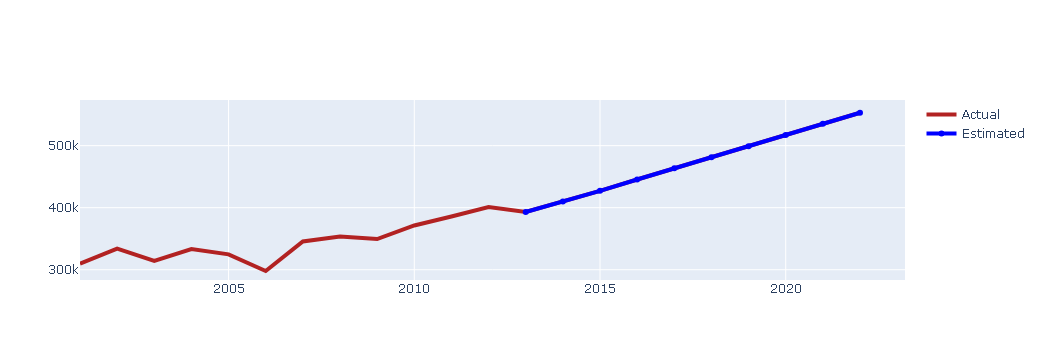

In [67]:
i=12
for j in range(len(forecast_df_TN)):
    crimes_TN_forecast.loc[i] = crimes_TN_forecast.YEAR[i-1]+1
    crimes_TN_forecast.loc[i, 'TOTAL IPC CRIMES'] = int(forecast_df_TN[j])
    i = i+1

fig = go.Figure()
fig.add_trace(go.Scatter(x= crimes_TN_forecast["YEAR"], y= crimes_TN_forecast['TOTAL IPC CRIMES'],
                    name = "Actual",line=dict(color='firebrick', width=4)))
fig.add_trace(go.Scatter(x= crimes_TN_forecast["YEAR"][12:], y= crimes_TN_forecast['TOTAL IPC CRIMES'][12:],
                    name = "Estimated",line=dict(color='blue', width=4)))

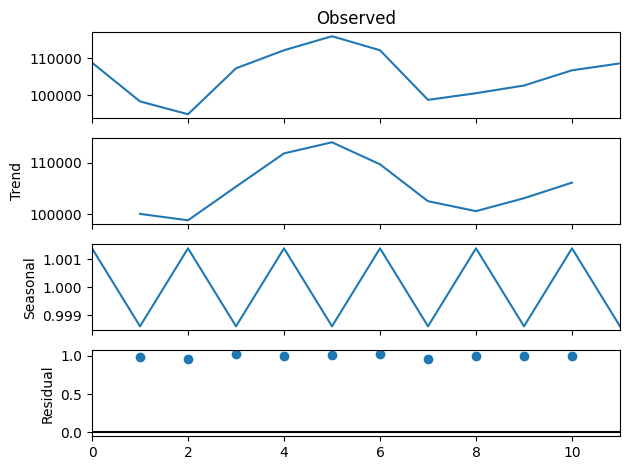

In [68]:
crime_DEL_df = crimes_total[crimes_total['STATE/UT']=='DELHI UT']
ts_decompose = sm.tsa.seasonal_decompose(np.array(crime_DEL_df['TOTAL IPC CRIMES']),
                                 model = "multiplicative", period=2)
ts_plot = ts_decompose.plot()

In [69]:
crimes_DEL_forecast = crime_DEL_df.copy()
crimes_DEL_forecast.drop(['STATE/UT'], axis = 1, inplace = True)
crimes_DEL_forecast = crimes_DEL_forecast.reset_index(drop = True)
crimes_DEL_forecast

,YEAR,TOTAL IPC CRIMES
0,2001,108768
1,2002,98274
2,2003,94808
3,2004,107246
4,2005,112130
5,2006,115926
6,2007,112130
7,2008,98700
8,2009,100502
9,2010,102584


In [70]:
DEL_arim = ARIMA(crimes_DEL_forecast['TOTAL IPC CRIMES'][0:10].astype(np.float64).to_numpy(), order=(1,2,0))
DEL_moDEL = DEL_arim.fit()
DEL_moDEL.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   10
Model:                 ARIMA(1, 2, 0)   Log Likelihood                 -84.471
Date:                Sat, 16 May 2026   AIC                            172.942
Time:                        14:29:27   BIC                            173.101
Sample:                             0   HQIC                           171.870
                                 - 10                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0611      0.437     -0.140      0.889      -0.917       0.795
sigma2      9.838e+07   1.84e-10   5.33e+17      0.000    9.84e+07    9.84e+07
===================================================================================
Ljung-Box (L1) (Q):                   0.51   Jarque-Bera (JB):                 0.90
Prob(Q):                              0.47   Prob(JB):                         0.64
Heteroskedasticity (H):               1.02   Skew:                             0.66
Prob(H) (two-sided):                  0.98   Kurtosis:                         2.01
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number    inf. Standard errors may be unstable.
"""

In [71]:
forecast_DEL = DEL_moDEL.predict(10,11)
print('prediction',forecast_DEL)
forecast_df_DEL = DEL_moDEL.forecast(steps=10)
print('forecasting',forecast_df_DEL)

prediction [104648.88108367 106714.80880054]
forecasting [104648.88108367 106714.80880054 108780.67252732 110846.54016639
 112912.40756626 114978.27498076 117044.14239436 119110.00980802
 121175.87722168 123241.74463533]


In [72]:
get_mape(crimes_DEL_forecast['TOTAL IPC CRIMES'][10:12],forecast_DEL)

np.float64(1.82)

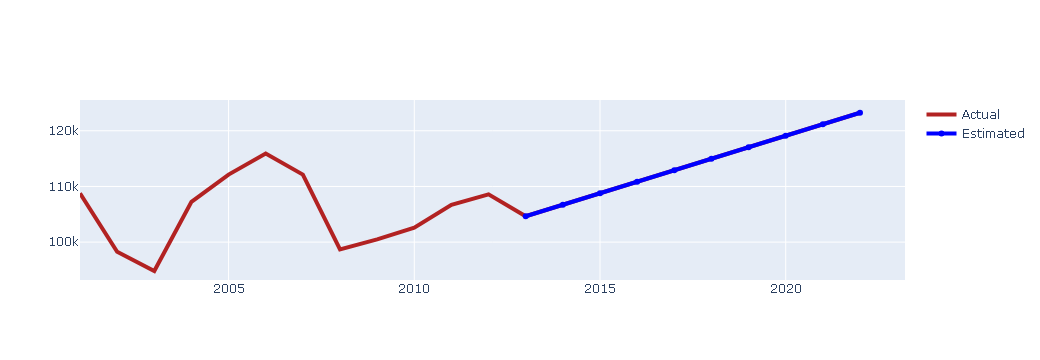

In [73]:
i=12
for j in range(len(forecast_df_DEL)):
    crimes_DEL_forecast.loc[i] = crimes_DEL_forecast.YEAR[i-1]+1
    crimes_DEL_forecast.loc[i, 'TOTAL IPC CRIMES']  = int(forecast_df_DEL[j])
    i = i+1

fig = go.Figure()
fig.add_trace(go.Scatter(x= crimes_DEL_forecast["YEAR"], y= crimes_DEL_forecast['TOTAL IPC CRIMES'],
                    name = "Actual",line=dict(color='firebrick', width=4)))
fig.add_trace(go.Scatter(x= crimes_DEL_forecast["YEAR"][12:], y= crimes_DEL_forecast['TOTAL IPC CRIMES'][12:],
                    name = "Estimated",line=dict(color='blue', width=4)))

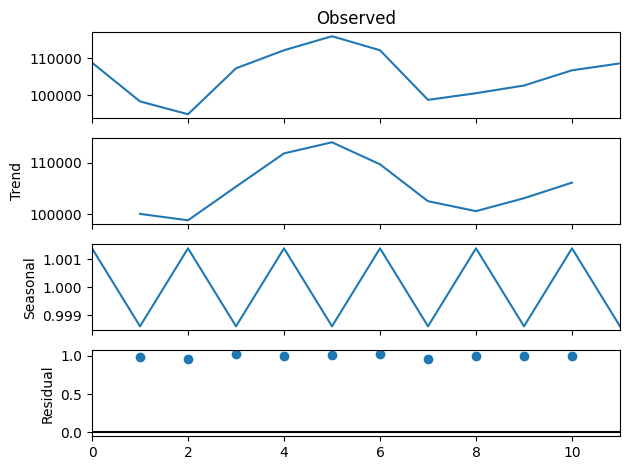

In [74]:
crime_LAK_df = crimes_total[crimes_total['STATE/UT']=='LAKSHADWEEP']
ts_decompose = sm.tsa.seasonal_decompose(np.array(crime_DEL_df['TOTAL IPC CRIMES']),
                                 model = "multiplicative", period=2)
ts_plot = ts_decompose.plot()

In [75]:
crimes_LAK_forecast = crime_LAK_df.copy()
crimes_LAK_forecast.drop(['STATE/UT'], axis = 1, inplace = True)
crimes_LAK_forecast = crimes_LAK_forecast.reset_index(drop = True)
plt.show()

In [76]:
LAK_arim = ARIMA(crimes_LAK_forecast['TOTAL IPC CRIMES'][0:10].astype(np.float64).to_numpy(), order=(2,1,0))
LAK_moLAK = LAK_arim.fit()
LAK_moLAK.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   10
Model:                 ARIMA(2, 1, 0)   Log Likelihood                 -50.318
Date:                Sat, 16 May 2026   AIC                            106.636
Time:                        14:29:29   BIC                            107.227
Sample:                             0   HQIC                           105.359
                                 - 10                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0057      0.374     -2.686      0.007      -1.740      -0.272
ar.L2         -0.4399      0.435     -1.012      0.312      -1.292       0.412
sigma2      3724.1250   2514.684      1.481      0.139   -1204.566    8652.815
===================================================================================
Ljung-Box (L1) (Q):                   1.72   Jarque-Bera (JB):                 0.06
Prob(Q):                              0.19   Prob(JB):                         0.97
Heteroskedasticity (H):               8.58   Skew:                             0.20
Prob(H) (two-sided):                  0.11   Kurtosis:                         2.93
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [77]:
forecast_LAK = LAK_moLAK.predict(10,11)
print('prediction',forecast_LAK)
forecast_df_LAK = LAK_moLAK.forecast(steps=10)
print('forecasting',forecast_df_LAK)

prediction [234.74319529 164.07998008]
forecasting [234.74319529 164.07998008 168.83353998 195.13918874 166.591164
 183.73072375 179.05166533 176.21748871 181.12638737 177.43610526]


In [78]:
get_mape(crimes_LAK_forecast['TOTAL IPC CRIMES'][10:12],forecast_LAK)

np.float64(101.74)

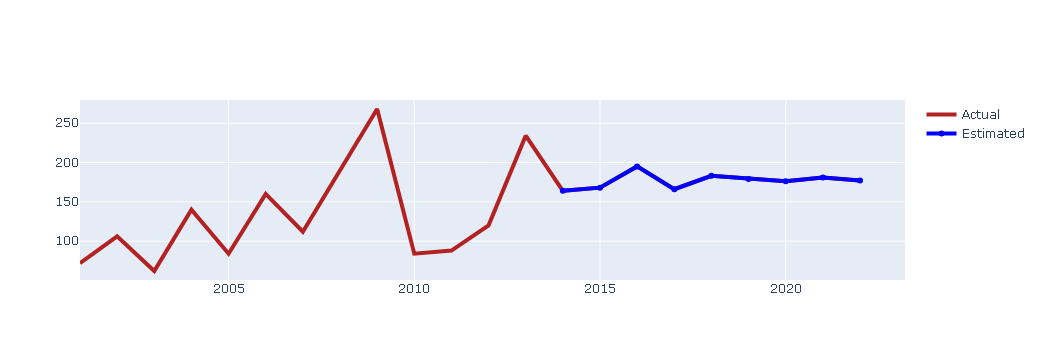

In [79]:
i=12
for j in range(len(forecast_df_LAK)):
    crimes_LAK_forecast.loc[i] = crimes_LAK_forecast.YEAR[i-1]+1
    crimes_LAK_forecast.loc[i, 'TOTAL IPC CRIMES'] = int(forecast_df_LAK[j])
    i = i+1

fig = go.Figure()
fig.add_trace(go.Scatter(x= crimes_LAK_forecast["YEAR"], y= crimes_LAK_forecast['TOTAL IPC CRIMES'],
                    name = "Actual",line=dict(color='firebrick', width=4)))
fig.add_trace(go.Scatter(x= crimes_LAK_forecast["YEAR"][13:], y= crimes_LAK_forecast['TOTAL IPC CRIMES'][13:],
                    name = "Estimated",line=dict(color='blue', width=4)))

In [80]:
#Crimes in UP
crimes_UP = df[df['STATE/UT']=="UTTAR PRADESH"]

In [81]:
crimes_UP.columns

Index(['STATE/UT', 'DISTRICT', 'YEAR', 'MURDER', 'ATTEMPT TO MURDER',
       'CULPABLE HOMICIDE NOT AMOUNTING TO MURDER', 'RAPE', 'CUSTODIAL RAPE',
       'OTHER RAPE', 'KIDNAPPING & ABDUCTION',
       'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
       'KIDNAPPING AND ABDUCTION OF OTHERS', 'DACOITY',
       'PREPARATION AND ASSEMBLY FOR DACOITY', 'ROBBERY', 'BURGLARY', 'THEFT',
       'AUTO THEFT', 'OTHER THEFT', 'RIOTS', 'CRIMINAL BREACH OF TRUST',
       'CHEATING', 'COUNTERFIETING', 'ARSON', 'HURT/GREVIOUS HURT',
       'DOWRY DEATHS', 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
       'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
       'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES',
       'CAUSING DEATH BY NEGLIGENCE', 'OTHER IPC CRIMES', 'TOTAL IPC CRIMES'],
      dtype='str')

In [82]:
# Countplot for crime types
Dist_UP = crimes_UP[crimes_UP.DISTRICT=='TOTAL']
Dist_UP = crimes_UP.groupby(["YEAR"]).agg({'THEFT':sum,'HURT/GREVIOUS HURT':sum,'KIDNAPPING & ABDUCTION':sum,'CRUELTY BY HUSBAND OR HIS RELATIVES':sum, 
                                                       'BURGLARY':sum, 'MURDER':sum,'CAUSING DEATH BY NEGLIGENCE':sum,
                                                      'CHEATING':sum, 'RIOTS':sum, 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY':sum}).reset_index()

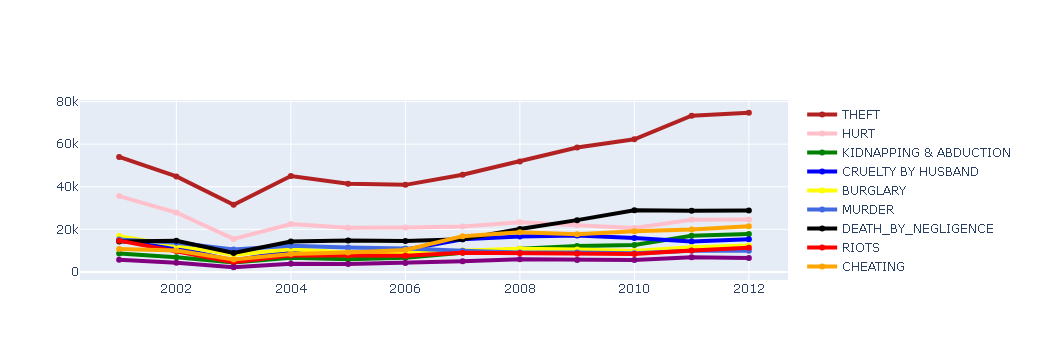

In [83]:
fig = go.Figure()
fig.add_trace(go.Scatter(x= Dist_UP["YEAR"], y= Dist_UP['THEFT'],
                    name = "THEFT",line=dict(color='firebrick', width=4)))
fig.add_trace(go.Scatter(x= Dist_UP["YEAR"], y= Dist_UP['HURT/GREVIOUS HURT'],
                    name='HURT',line=dict(color='pink', width=4)))
fig.add_trace(go.Scatter(x= Dist_UP["YEAR"], y= Dist_UP['KIDNAPPING & ABDUCTION'],
                    name='KIDNAPPING & ABDUCTION',line=dict(color='green', width=4)))
fig.add_trace(go.Scatter(x= Dist_UP["YEAR"], y= Dist_UP["CRUELTY BY HUSBAND OR HIS RELATIVES"],
                    name='CRUELTY BY HUSBAND',line=dict(color='blue', width=4)))
fig.add_trace(go.Scatter(x= Dist_UP["YEAR"], y= Dist_UP['BURGLARY'],
                    name='BURGLARY',line=dict(color='yellow', width=4)))
fig.add_trace(go.Scatter(x= Dist_UP["YEAR"], y= Dist_UP['MURDER'],
                    name='MURDER',line=dict(color='royalblue', width=4)))
fig.add_trace(go.Scatter(x= Dist_UP["YEAR"], y= Dist_UP['CAUSING DEATH BY NEGLIGENCE'],
                    name='DEATH_BY_NEGLIGENCE',line=dict(color='black', width=4)))
fig.add_trace(go.Scatter(x= Dist_UP["YEAR"], y= Dist_UP['RIOTS'],
                    name='RIOTS',line=dict(color='red', width=4)))
fig.add_trace(go.Scatter(x= Dist_UP["YEAR"], y= Dist_UP['CHEATING'],
                    name='CHEATING',line=dict(color='orange', width=4)))
fig.add_trace(go.Scatter(x= Dist_UP["YEAR"], y= Dist_UP['ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY'],
                    name='ASSAULT_WOMEN_MODESTY',line=dict(color='purple', width=4)))
fig.update_layout(uniformtext_minsize= 20)
fig.show()

In [84]:
crimes_theft = crimes_UP[crimes_UP.DISTRICT!="TOTAL"]
crimes_theft = crimes_theft.groupby('DISTRICT').agg({"THEFT":sum, 'HURT/GREVIOUS HURT':sum, 'CAUSING DEATH BY NEGLIGENCE':sum}).reset_index()
crimes_theft.head(5)

,DISTRICT,THEFT,HURT/GREVIOUS HURT,CAUSING DEATH BY NEGLIGENCE
0,AGRA,20725,5381,4605
1,ALIGARH,10393,3756,3103
2,ALLAHABAD,9178,5073,3812
3,AMBEDKAR NAGAR,1343,1911,599
4,AURAIYA,1044,1526,1490


In [85]:
crimes_large = crimes_theft[(crimes_theft.THEFT>10000) & (crimes_theft['HURT/GREVIOUS HURT']>5000) & (crimes_theft['CAUSING DEATH BY NEGLIGENCE']>2000)].reset_index()

crimes_large

,index,DISTRICT,THEFT,HURT/GREVIOUS HURT,CAUSING DEATH BY NEGLIGENCE
0,0,AGRA,20725,5381,4605
1,43,KANPUR NAGAR,13894,5567,4043


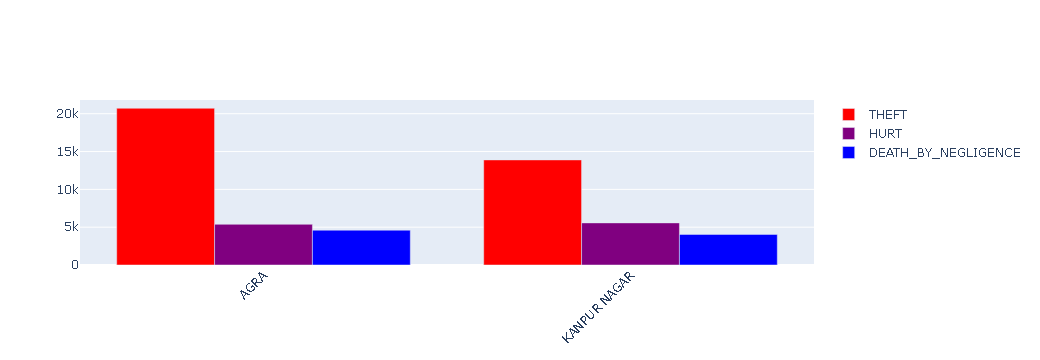

In [86]:
fig = go.Figure()
fig.add_trace(go.Bar(
    x=crimes_large["DISTRICT"],
    y=crimes_large["THEFT"],
    name='THEFT',
    marker_color='red'
))
fig.add_trace(go.Bar(
    x=crimes_large["DISTRICT"],
    y=crimes_large["HURT/GREVIOUS HURT"],
    name='HURT',
    marker_color='Purple'
))
fig.add_trace(go.Bar(
    x=crimes_large["DISTRICT"],
    y=crimes_large["CAUSING DEATH BY NEGLIGENCE"],
    name='DEATH_BY_NEGLIGENCE',
    marker_color='blue'
))
fig.update_layout(barmode='group', xaxis_tickangle=-45)
fig.show()

In [87]:
crimes_up_clus = crimes_UP.copy()

In [88]:
crimes_up_clus.columns

Index(['STATE/UT', 'DISTRICT', 'YEAR', 'MURDER', 'ATTEMPT TO MURDER',
       'CULPABLE HOMICIDE NOT AMOUNTING TO MURDER', 'RAPE', 'CUSTODIAL RAPE',
       'OTHER RAPE', 'KIDNAPPING & ABDUCTION',
       'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
       'KIDNAPPING AND ABDUCTION OF OTHERS', 'DACOITY',
       'PREPARATION AND ASSEMBLY FOR DACOITY', 'ROBBERY', 'BURGLARY', 'THEFT',
       'AUTO THEFT', 'OTHER THEFT', 'RIOTS', 'CRIMINAL BREACH OF TRUST',
       'CHEATING', 'COUNTERFIETING', 'ARSON', 'HURT/GREVIOUS HURT',
       'DOWRY DEATHS', 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
       'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
       'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES',
       'CAUSING DEATH BY NEGLIGENCE', 'OTHER IPC CRIMES', 'TOTAL IPC CRIMES'],
      dtype='str')

In [89]:
crimes_up_clus.drop(["STATE/UT", 'TOTAL IPC CRIMES', 'YEAR', 'ATTEMPT TO MURDER',
       'CULPABLE HOMICIDE NOT AMOUNTING TO MURDER', 'RAPE', 'CUSTODIAL RAPE',
       'OTHER RAPE',  'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
       'KIDNAPPING AND ABDUCTION OF OTHERS', 'DACOITY',
       'PREPARATION AND ASSEMBLY FOR DACOITY', 'ROBBERY', 'THEFT',
       'AUTO THEFT', 'OTHER THEFT', 'COUNTERFIETING', 'ARSON', 'DOWRY DEATHS', 'INSULT TO MODESTY OF WOMEN', 'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES'], axis=1 ,inplace = True)

In [90]:
crimes_up_main = crimes_up_clus[crimes_up_clus.DISTRICT!="TOTAL"]

In [91]:
crimes_up_df = crimes_up_main.groupby("DISTRICT").agg({'HURT/GREVIOUS HURT':sum,'KIDNAPPING & ABDUCTION':sum,'CRUELTY BY HUSBAND OR HIS RELATIVES':sum, 
                                                       'BURGLARY':sum, 'MURDER':sum,'CAUSING DEATH BY NEGLIGENCE':sum,
                                                      'CHEATING':sum, 'RIOTS':sum, 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY':sum, 'OTHER IPC CRIMES':sum}).reset_index()
       

In [92]:
scale = StandardScaler()
scale_new = scale.fit_transform(crimes_up_df[['HURT/GREVIOUS HURT','KIDNAPPING & ABDUCTION','CRUELTY BY HUSBAND OR HIS RELATIVES', 
                                                       'BURGLARY', 'MURDER','CAUSING DEATH BY NEGLIGENCE',
                                                      'CHEATING', 'RIOTS', 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY', 'OTHER IPC CRIMES']])

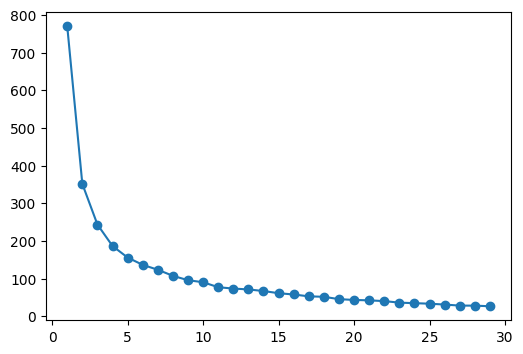

In [93]:
cluster_range = range(1,30)
cluster_error = []

for x in cluster_range:
    cluster = KMeans(x)
    cluster.fit(scale_new)
    cluster_error.append(cluster.inertia_)
    
plt.figure(figsize=(6,4))
plt.plot(cluster_range, cluster_error, marker = "o")

In [94]:
k = 3
cluster_new = KMeans(3, random_state = 42)
cluster_new.fit(scale_new)
crimes_up_df['Cluster_ID'] = cluster_new.labels_

In [95]:
crimes_up_df[crimes_up_df.Cluster_ID == 0]

,DISTRICT,HURT/GREVIOUS HURT,KIDNAPPING & ABDUCTION,CRUELTY BY HUSBAND OR HIS RELATIVES,BURGLARY,MURDER,CAUSING DEATH BY NEGLIGENCE,CHEATING,RIOTS,ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY,OTHER IPC CRIMES,Cluster_ID
3,AMBEDKAR NAGAR,1911,533,919,508,430,599,610,381,173,3316,0
4,AURAIYA,1526,584,342,292,484,1490,332,279,187,4032,0
7,BAGHPAT,1111,530,784,420,949,943,588,598,185,4367,0
8,BAHRAICH,1965,765,447,797,573,913,975,555,284,7078,0
9,BALLIA,1926,350,339,773,436,821,482,744,158,3784,0
10,BALRAMPUR,722,260,182,271,228,321,378,146,133,1493,0
11,BANDA,1158,348,391,669,606,515,562,443,500,6591,0
14,BASTI,1542,301,357,467,373,986,581,420,123,4927,0
15,BHIM NAGAR,152,207,125,156,149,179,79,135,73,1393,0
18,CHANDOLI,1297,182,512,366,306,443,518,92,99,3345,0


In [96]:
crimes_up_df[crimes_up_df.Cluster_ID == 1]

,DISTRICT,HURT/GREVIOUS HURT,KIDNAPPING & ABDUCTION,CRUELTY BY HUSBAND OR HIS RELATIVES,BURGLARY,MURDER,CAUSING DEATH BY NEGLIGENCE,CHEATING,RIOTS,ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY,OTHER IPC CRIMES,Cluster_ID
5,AZAMGARH,3354,698,1016,982,967,1135,861,1110,251,6694,1
6,BADAUN,3487,1007,542,686,1742,658,637,329,495,11356,1
12,BARABANKI,2993,898,1142,993,753,1807,545,366,394,9715,1
16,BIJNOR,3313,955,2144,653,1078,1983,1683,613,442,7214,1
17,BULANDSHAHAR,2073,1317,2386,853,1974,2882,1622,1035,722,13332,1
22,ETAH,3040,928,907,699,1477,1660,1025,1071,492,9633,1
26,FATEHPUR,2370,610,537,568,990,2138,822,211,364,7061,1
27,FIROZABAD,3403,1361,1123,755,1406,1024,1063,1137,480,10536,1
29,GAUTAMBUDH NAGAR,407,882,882,1294,944,2340,2415,943,392,10133,1
33,GORAKHPUR,3778,1272,1535,1887,1109,3010,2140,1645,439,10022,1


In [97]:
crimes_up_df[crimes_up_df.Cluster_ID == 2]

,DISTRICT,HURT/GREVIOUS HURT,KIDNAPPING & ABDUCTION,CRUELTY BY HUSBAND OR HIS RELATIVES,BURGLARY,MURDER,CAUSING DEATH BY NEGLIGENCE,CHEATING,RIOTS,ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY,OTHER IPC CRIMES,Cluster_ID
0,AGRA,5381,2541,4003,3063,1609,4605,3323,3279,1278,20143,2
1,ALIGARH,3756,2134,2754,1875,2032,3103,2768,2823,994,13804,2
2,ALLAHABAD,5073,1425,2316,2861,1652,3812,2385,1847,665,20104,2
13,BAREILLY,4640,1754,2570,1662,2070,2630,2518,1290,1075,19471,2
30,GHAZIABAD,731,2340,2922,2237,2227,4719,3665,1299,534,19741,2
43,KANPUR NAGAR,5567,2636,4341,2849,1961,4043,4427,1945,1083,22257,2
49,LUCKNOW,793,2914,5598,6663,1828,5058,7731,2909,1402,43505,2
55,MEERUT,689,2082,3746,2255,2398,3279,3072,1963,831,17894,2


In [98]:
#crimes in Delhi
crimes_DEL = df[df['STATE/UT']=="DELHI UT"]
crimes_DEL.shape

(183, 33)

In [99]:
crimes_DEL.columns

Index(['STATE/UT', 'DISTRICT', 'YEAR', 'MURDER', 'ATTEMPT TO MURDER',
       'CULPABLE HOMICIDE NOT AMOUNTING TO MURDER', 'RAPE', 'CUSTODIAL RAPE',
       'OTHER RAPE', 'KIDNAPPING & ABDUCTION',
       'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
       'KIDNAPPING AND ABDUCTION OF OTHERS', 'DACOITY',
       'PREPARATION AND ASSEMBLY FOR DACOITY', 'ROBBERY', 'BURGLARY', 'THEFT',
       'AUTO THEFT', 'OTHER THEFT', 'RIOTS', 'CRIMINAL BREACH OF TRUST',
       'CHEATING', 'COUNTERFIETING', 'ARSON', 'HURT/GREVIOUS HURT',
       'DOWRY DEATHS', 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
       'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
       'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES',
       'CAUSING DEATH BY NEGLIGENCE', 'OTHER IPC CRIMES', 'TOTAL IPC CRIMES'],
      dtype='str')

In [100]:
Dist_DEL = crimes_DEL[crimes_DEL.DISTRICT=='TOTAL']

In [101]:
Dist_DEL = crimes_DEL.groupby(['YEAR']).agg({'THEFT':sum,'HURT/GREVIOUS HURT':sum,'KIDNAPPING & ABDUCTION':sum,'CRUELTY BY HUSBAND OR HIS RELATIVES':sum, 
                                                       'BURGLARY':sum, 'MURDER':sum,'CAUSING DEATH BY NEGLIGENCE':sum,
                                                      'CHEATING':sum, 'RIOTS':sum, 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY':sum}).reset_index()

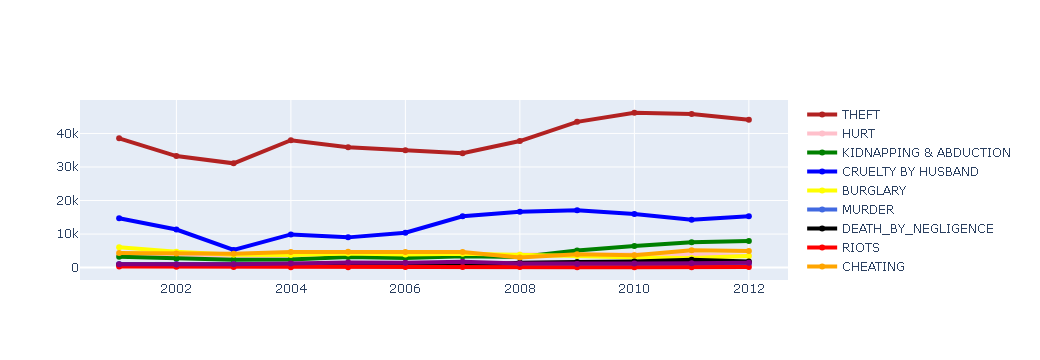

In [102]:
fig = go.Figure()
fig.add_trace(go.Scatter(x= Dist_DEL["YEAR"], y= Dist_DEL['THEFT'],
                    name = "THEFT",line=dict(color='firebrick', width=4)))
fig.add_trace(go.Scatter(x= Dist_DEL["YEAR"], y= Dist_DEL['HURT/GREVIOUS HURT'],
                    name='HURT',line=dict(color='pink', width=4)))
fig.add_trace(go.Scatter(x= Dist_DEL["YEAR"], y= Dist_DEL['KIDNAPPING & ABDUCTION'],
                    name='KIDNAPPING & ABDUCTION',line=dict(color='green', width=4)))
fig.add_trace(go.Scatter(x= Dist_DEL["YEAR"], y= Dist_UP["CRUELTY BY HUSBAND OR HIS RELATIVES"],
                    name='CRUELTY BY HUSBAND',line=dict(color='blue', width=4)))
fig.add_trace(go.Scatter(x= Dist_DEL["YEAR"], y= Dist_DEL['BURGLARY'],
                    name='BURGLARY',line=dict(color='yellow', width=4)))
fig.add_trace(go.Scatter(x= Dist_DEL["YEAR"], y= Dist_DEL['MURDER'],
                    name='MURDER',line=dict(color='royalblue', width=4)))
fig.add_trace(go.Scatter(x= Dist_DEL["YEAR"], y= Dist_DEL['CAUSING DEATH BY NEGLIGENCE'],
                    name='DEATH_BY_NEGLIGENCE',line=dict(color='black', width=4)))
fig.add_trace(go.Scatter(x= Dist_DEL["YEAR"], y= Dist_DEL['RIOTS'],
                    name='RIOTS',line=dict(color='red', width=4)))
fig.add_trace(go.Scatter(x= Dist_DEL["YEAR"], y= Dist_DEL['CHEATING'],
                    name='CHEATING',line=dict(color='orange', width=4)))
fig.add_trace(go.Scatter(x= Dist_DEL["YEAR"], y= Dist_DEL['ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY'],
                    name='ASSAULT_WOMEN_MODESTY',line=dict(color='purple', width=4)))
fig.update_layout(uniformtext_minsize= 20)
fig.show()

In [103]:
crimes_all = crimes_DEL[crimes_DEL.DISTRICT!="TOTAL"]
crimes_all = crimes_all.groupby('DISTRICT').agg({"THEFT":sum, 'CRUELTY BY HUSBAND OR HIS RELATIVES':sum}).reset_index()

In [104]:
crimes_del = crimes_all[(crimes_all.THEFT>10000) & (crimes_all['CRUELTY BY HUSBAND OR HIS RELATIVES']>1000)].reset_index()
crimes_del

,index,DISTRICT,THEFT,CRUELTY BY HUSBAND OR HIS RELATIVES
0,3,DELHI UT TOTAL,231546,15211
1,4,EAST,29165,1860
2,14,NORTH-EAST,15265,1638
3,15,NORTH-WEST,17635,1581
4,16,OUTER,11625,1107
5,18,SOUTH,37467,1443
6,21,SOUTH-WEST,11290,1209
7,24,WEST,27033,2387


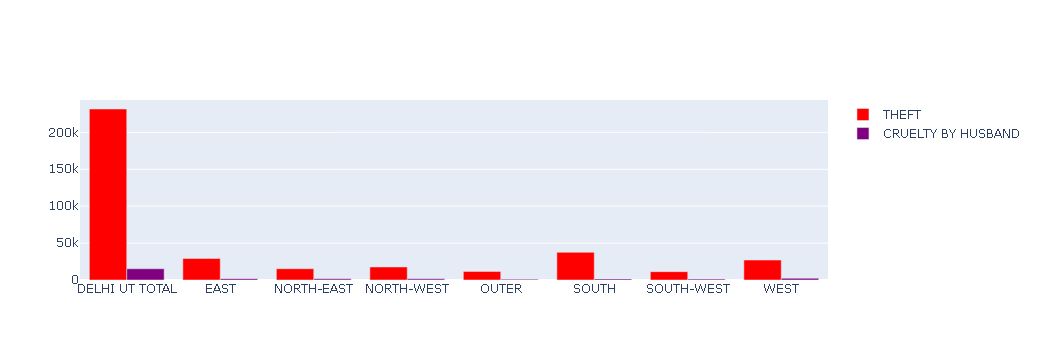

In [105]:
fig = go.Figure()
fig.add_trace(go.Bar(
    x=crimes_del["DISTRICT"],
    y=crimes_del["THEFT"],
    name='THEFT',
    marker_color='red'
))
fig.add_trace(go.Bar(
    x=crimes_del["DISTRICT"],
    y=crimes_del["CRUELTY BY HUSBAND OR HIS RELATIVES"],
    name='CRUELTY BY HUSBAND',
    marker_color='Purple'
))

In [106]:
crimes_del_clus = crimes_DEL.copy()
crimes_del_clus.columns

Index(['STATE/UT', 'DISTRICT', 'YEAR', 'MURDER', 'ATTEMPT TO MURDER',
       'CULPABLE HOMICIDE NOT AMOUNTING TO MURDER', 'RAPE', 'CUSTODIAL RAPE',
       'OTHER RAPE', 'KIDNAPPING & ABDUCTION',
       'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
       'KIDNAPPING AND ABDUCTION OF OTHERS', 'DACOITY',
       'PREPARATION AND ASSEMBLY FOR DACOITY', 'ROBBERY', 'BURGLARY', 'THEFT',
       'AUTO THEFT', 'OTHER THEFT', 'RIOTS', 'CRIMINAL BREACH OF TRUST',
       'CHEATING', 'COUNTERFIETING', 'ARSON', 'HURT/GREVIOUS HURT',
       'DOWRY DEATHS', 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
       'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
       'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES',
       'CAUSING DEATH BY NEGLIGENCE', 'OTHER IPC CRIMES', 'TOTAL IPC CRIMES'],
      dtype='str')

In [107]:
crimes_del_clus.drop(["STATE/UT", 'TOTAL IPC CRIMES', 'YEAR', 'ATTEMPT TO MURDER',
       'CULPABLE HOMICIDE NOT AMOUNTING TO MURDER', 'RAPE', 'CUSTODIAL RAPE',
       'OTHER RAPE',  'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
       'KIDNAPPING AND ABDUCTION OF OTHERS', 'DACOITY',
       'PREPARATION AND ASSEMBLY FOR DACOITY', 'ROBBERY', 'THEFT',
       'AUTO THEFT', 'OTHER THEFT', 'COUNTERFIETING', 'ARSON', 'DOWRY DEATHS', 'INSULT TO MODESTY OF WOMEN', 'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES'], axis=1 ,inplace = True)

In [108]:
crimes_del_main = crimes_del_clus[crimes_del_clus.DISTRICT!="TOTAL"]

In [109]:
crimes_del_df = crimes_del_main.groupby("DISTRICT").agg({'HURT/GREVIOUS HURT':sum,'KIDNAPPING & ABDUCTION':sum,'CRUELTY BY HUSBAND OR HIS RELATIVES':sum, 
                                                       'BURGLARY':sum, 'MURDER':sum,'CAUSING DEATH BY NEGLIGENCE':sum,
                                                      'CHEATING':sum, 'RIOTS':sum, 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY':sum, 'OTHER IPC CRIMES':sum}).reset_index()        

In [110]:
scaled = StandardScaler()
scaled_new = scaled.fit_transform(crimes_del_df[['HURT/GREVIOUS HURT','KIDNAPPING & ABDUCTION','CRUELTY BY HUSBAND OR HIS RELATIVES', 
                                                       'BURGLARY', 'MURDER','CAUSING DEATH BY NEGLIGENCE',
                                                      'CHEATING', 'RIOTS', 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY', 'OTHER IPC CRIMES']])

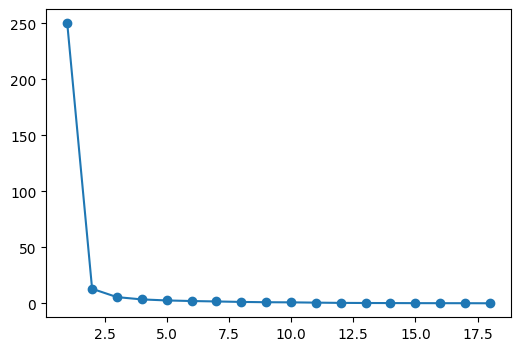

In [111]:
new_range = range(1,19)
rate_error = []
for i in new_range:
    cluster_df = KMeans(i)
    cluster_df.fit(scaled_new)
    rate_error.append(cluster_df.inertia_)
    
plt.figure(figsize=(6,4))
plt.plot(new_range, rate_error, marker="o")

In [112]:
k = 2
clusterdel = KMeans(2, random_state=42)
clusterdel.fit(scaled_new)
crimes_del_df['cluster_id'] = clusterdel.labels_

In [113]:
crimes_del_df[crimes_del_df.cluster_id == 0]

,DISTRICT,HURT/GREVIOUS HURT,KIDNAPPING & ABDUCTION,CRUELTY BY HUSBAND OR HIS RELATIVES,BURGLARY,MURDER,CAUSING DEATH BY NEGLIGENCE,CHEATING,RIOTS,ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY,OTHER IPC CRIMES,cluster_id
0,CAW,2,0,789,0,0,0,0,0,3,1,0
1,CENTRAL,1755,1085,606,1065,316,124,1963,54,419,13559,0
2,CRIME BRANCH,0,4,0,0,4,0,218,0,0,104,0
4,EAST,2649,2793,1860,2253,570,985,1850,148,1000,21920,0
5,EOW,0,0,0,0,0,0,672,0,1,90,0
6,G.R.P.(RLY),49,25,0,8,43,4,93,3,18,410,0
7,GRP(RLY),59,115,2,9,58,4,72,5,27,598,0
8,I.G.I. AIRPORT,14,12,1,2,9,4,2016,7,14,310,0
9,IGI AIRPORT,6,35,2,5,8,40,2782,3,36,1426,0
10,NEW DELHI,394,303,94,590,86,749,2500,93,266,8325,0


In [114]:
crimes_del_df[crimes_del_df.cluster_id == 1]

,DISTRICT,HURT/GREVIOUS HURT,KIDNAPPING & ABDUCTION,CRUELTY BY HUSBAND OR HIS RELATIVES,BURGLARY,MURDER,CAUSING DEATH BY NEGLIGENCE,CHEATING,RIOTS,ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY,OTHER IPC CRIMES,cluster_id
3,DELHI UT TOTAL,22210,25083,15211,23555,6205,7503,26128,996,7534,237457,1


In [115]:
crimes_AS = df[df['STATE/UT']=='ASSAM']
crimes_AS.shape

(362, 33)

In [116]:
DIST_AS = crimes_AS[crimes_AS.DISTRICT=='TOTAL']
DIST_AS = crimes_AS.groupby(['YEAR']).agg({'THEFT':sum,'HURT/GREVIOUS HURT':sum,'KIDNAPPING & ABDUCTION':sum,'CRUELTY BY HUSBAND OR HIS RELATIVES':sum, 
                                                       'BURGLARY':sum, 'MURDER':sum,'CAUSING DEATH BY NEGLIGENCE':sum,
                                                      'CHEATING':sum, 'RIOTS':sum, 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY':sum}).reset_index()

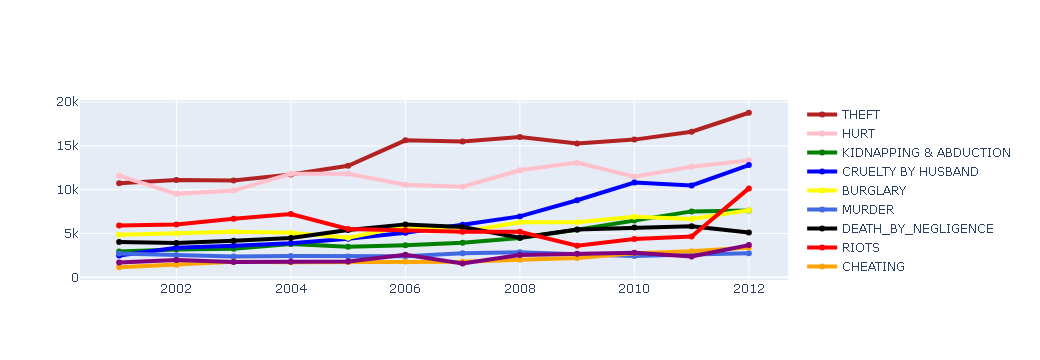

In [117]:
fig = go.Figure()
fig.add_trace(go.Scatter(x= DIST_AS["YEAR"], y= DIST_AS['THEFT'],
                    name = "THEFT",line=dict(color='firebrick', width=4)))
fig.add_trace(go.Scatter(x= DIST_AS["YEAR"], y= DIST_AS['HURT/GREVIOUS HURT'],
                    name='HURT',line=dict(color='pink', width=4)))
fig.add_trace(go.Scatter(x= DIST_AS["YEAR"], y= DIST_AS['KIDNAPPING & ABDUCTION'],
                    name='KIDNAPPING & ABDUCTION',line=dict(color='green', width=4)))
fig.add_trace(go.Scatter(x= DIST_AS["YEAR"], y= DIST_AS["CRUELTY BY HUSBAND OR HIS RELATIVES"],
                    name='CRUELTY BY HUSBAND',line=dict(color='blue', width=4)))
fig.add_trace(go.Scatter(x= DIST_AS["YEAR"], y= DIST_AS['BURGLARY'],
                    name='BURGLARY',line=dict(color='yellow', width=4)))
fig.add_trace(go.Scatter(x= DIST_AS["YEAR"], y= DIST_AS['MURDER'],
                    name='MURDER',line=dict(color='royalblue', width=4)))
fig.add_trace(go.Scatter(x= DIST_AS["YEAR"], y= DIST_AS['CAUSING DEATH BY NEGLIGENCE'],
                    name='DEATH_BY_NEGLIGENCE',line=dict(color='black', width=4)))
fig.add_trace(go.Scatter(x= DIST_AS["YEAR"], y= DIST_AS['RIOTS'],
                    name='RIOTS',line=dict(color='red', width=4)))
fig.add_trace(go.Scatter(x= DIST_AS["YEAR"], y= DIST_AS['CHEATING'],
                    name='CHEATING',line=dict(color='orange', width=4)))
fig.add_trace(go.Scatter(x= DIST_AS["YEAR"], y= DIST_AS['ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY'],
                    name='ASSAULT_WOMEN_MODESTY',line=dict(color='purple', width=4)))
fig.update_layout(uniformtext_minsize= 20)
fig.show()

In [118]:
crimes_AS_df = crimes_AS[crimes_AS.DISTRICT!="TOTAL"]
crimes_AS_df = crimes_AS_df.groupby('DISTRICT').agg({"THEFT":sum, 'HURT/GREVIOUS HURT':sum, 'CRUELTY BY HUSBAND OR HIS RELATIVES':sum}).reset_index()
crimes_AS_df

,DISTRICT,THEFT,HURT/GREVIOUS HURT,CRUELTY BY HUSBAND OR HIS RELATIVES
0,BAKSA,104,66,15
1,BARPETA,2355,2071,2424
2,BASKA,290,513,114
3,BIEO,0,0,0
4,BONGAIGAON,1316,1118,1101
5,C.I.D.,14,0,0
6,CACHAR,5861,2856,4172
7,CHIRANG,432,252,402
8,DARRANG,2036,3235,1645
9,DHEMAJI,1398,2385,1058


In [119]:
AS_crimes = crimes_AS_df[(crimes_AS_df.THEFT>1000) & (crimes_AS_df['HURT/GREVIOUS HURT']>5000) & (crimes_AS_df['CRUELTY BY HUSBAND OR HIS RELATIVES']>2000)].reset_index()

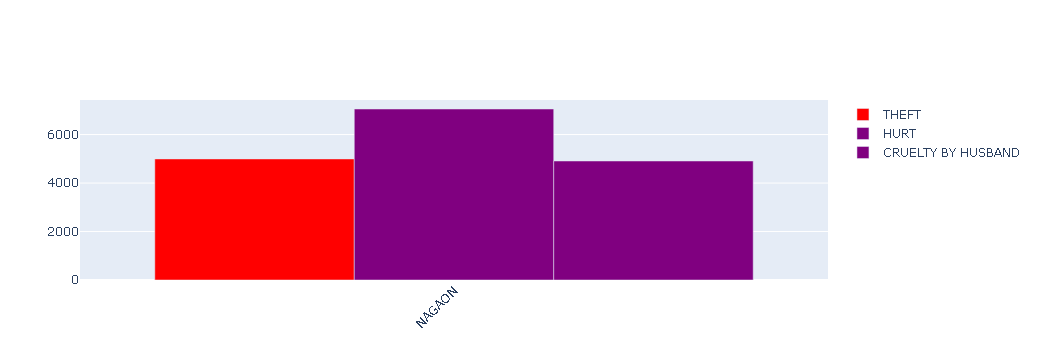

In [120]:
fig = go.Figure()
fig.add_trace(go.Bar(
    x=AS_crimes["DISTRICT"],
    y=AS_crimes["THEFT"],
    name='THEFT',
    marker_color='red'
))
fig.add_trace(go.Bar(
    x=AS_crimes["DISTRICT"],
    y=AS_crimes["HURT/GREVIOUS HURT"],
    name='HURT',
    marker_color='Purple'
))
fig.add_trace(go.Bar(
    x=AS_crimes["DISTRICT"],
    y=AS_crimes["CRUELTY BY HUSBAND OR HIS RELATIVES"],
    name='CRUELTY BY HUSBAND',
    marker_color='Purple'
))
fig.update_layout(barmode='group', xaxis_tickangle=-45)
fig.show()

In [121]:
crimes_AS_clus = crimes_AS.copy()

In [122]:
crimes_AS_clus.drop(["STATE/UT", 'TOTAL IPC CRIMES', 'YEAR', 'ATTEMPT TO MURDER',
       'CULPABLE HOMICIDE NOT AMOUNTING TO MURDER', 'RAPE', 'CUSTODIAL RAPE',
       'OTHER RAPE',  'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
       'KIDNAPPING AND ABDUCTION OF OTHERS', 'DACOITY',
       'PREPARATION AND ASSEMBLY FOR DACOITY', 'ROBBERY', 'THEFT',
       'AUTO THEFT', 'OTHER THEFT', 'COUNTERFIETING', 'ARSON', 'DOWRY DEATHS', 'INSULT TO MODESTY OF WOMEN', 'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES'], axis=1 ,inplace = True)

In [123]:
crimes_AS_main = crimes_AS_clus[crimes_AS_clus.DISTRICT!="TOTAL"]
crimes_KMe_AS = crimes_AS_main.groupby("DISTRICT").agg({'HURT/GREVIOUS HURT':sum,'KIDNAPPING & ABDUCTION':sum,'CRUELTY BY HUSBAND OR HIS RELATIVES':sum, 
                                                       'BURGLARY':sum, 'MURDER':sum,'CAUSING DEATH BY NEGLIGENCE':sum,
                                                      'CHEATING':sum, 'RIOTS':sum, 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY':sum, 'OTHER IPC CRIMES':sum}).reset_index()


In [124]:
scaled = StandardScaler()
scaled_AS = scaled.fit_transform(crimes_KMe_AS[['HURT/GREVIOUS HURT','KIDNAPPING & ABDUCTION','CRUELTY BY HUSBAND OR HIS RELATIVES', 
                                                       'BURGLARY', 'MURDER','CAUSING DEATH BY NEGLIGENCE',
                                                      'CHEATING', 'RIOTS', 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY', 'OTHER IPC CRIMES']])


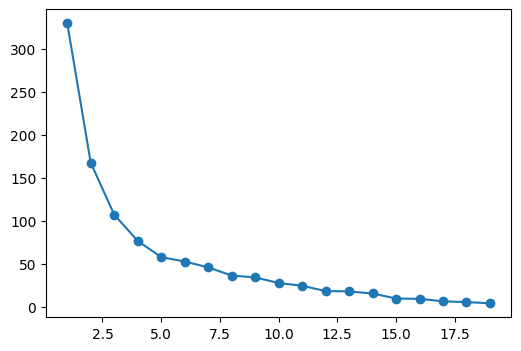

In [125]:
new_AS = range(1,20)
rate_AS = []
for i in new_AS:
    clustering = KMeans(i)
    clustering.fit(scaled_AS)
    rate_AS.append(clustering.inertia_)
    
plt.figure(figsize=(6,4))
plt.plot(new_AS, rate_AS, marker="o")

In [126]:
K=4
cluster_AS = KMeans(4, random_state = 42)
cluster_AS.fit(scaled_AS)
crimes_KMe_AS['Cluster_id'] = cluster_AS.labels_

In [127]:
crimes_KMe_AS[crimes_KMe_AS.Cluster_id==0]

,DISTRICT,HURT/GREVIOUS HURT,KIDNAPPING & ABDUCTION,CRUELTY BY HUSBAND OR HIS RELATIVES,BURGLARY,MURDER,CAUSING DEATH BY NEGLIGENCE,CHEATING,RIOTS,ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY,OTHER IPC CRIMES,Cluster_id
0,BAKSA,66,62,15,22,38,31,14,3,4,233,0
2,BASKA,513,256,114,132,273,137,64,38,83,999,0
3,BIEO,0,0,0,0,0,0,0,0,0,0,0
5,C.I.D.,0,8,0,0,2,0,97,0,0,236,0
7,CHIRANG,252,281,402,265,214,184,66,184,91,1662,0
12,G.R.P.,104,45,30,54,91,33,65,107,12,1261,0
16,HAILAKANDI,616,654,779,773,262,279,234,1841,235,4505,0
17,HAMREN,21,16,3,19,9,9,1,3,2,13,0
20,KARBI ANGLONG,639,450,183,287,632,521,95,424,105,2357,0
25,N.C.HILLS,286,166,92,139,294,139,44,57,26,609,0


In [128]:
crimes_KMe_AS[crimes_KMe_AS.Cluster_id==1]

,DISTRICT,HURT/GREVIOUS HURT,KIDNAPPING & ABDUCTION,CRUELTY BY HUSBAND OR HIS RELATIVES,BURGLARY,MURDER,CAUSING DEATH BY NEGLIGENCE,CHEATING,RIOTS,ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY,OTHER IPC CRIMES,Cluster_id
1,BARPETA,2071,1366,2424,1665,567,1407,438,2619,467,10333,1
4,BONGAIGAON,1118,619,1101,926,298,807,237,829,175,4284,1
8,DARRANG,3235,1079,1645,1291,471,1125,482,675,1438,5432,1
9,DHEMAJI,2385,637,1058,363,253,478,239,236,374,2802,1
13,GOALPARA,1767,829,1923,834,414,902,390,1288,400,5262,1
14,GOLAGHAT,3772,1120,1227,998,735,1442,447,140,500,3368,1
18,JORHAT,2818,670,1082,1048,506,1133,458,446,516,4674,1
19,KAMRUP,2308,1317,1070,1526,450,931,580,1089,498,11365,1
21,KARIMGANJ,1247,586,1279,890,423,420,192,1927,89,4920,1
22,KOKRAJHAR,1874,693,762,562,709,694,249,3523,342,2457,1


In [129]:
crimes_KMe_AS[crimes_KMe_AS.Cluster_id==2]

,DISTRICT,HURT/GREVIOUS HURT,KIDNAPPING & ABDUCTION,CRUELTY BY HUSBAND OR HIS RELATIVES,BURGLARY,MURDER,CAUSING DEATH BY NEGLIGENCE,CHEATING,RIOTS,ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY,OTHER IPC CRIMES,Cluster_id
6,CACHAR,2856,1591,4172,2572,695,2681,710,3769,920,19550,2
10,DHUBRI,4885,1795,4331,1286,634,1905,953,5698,1549,6385,2
15,GUWAHATI CITY,6441,2959,1932,6701,698,2459,2273,2037,1098,26625,2
26,NAGAON,7055,2606,4910,3297,996,3137,831,3192,1125,13736,2


In [130]:
crimes_KMe_AS[crimes_KMe_AS.Cluster_id==3]

,DISTRICT,HURT/GREVIOUS HURT,KIDNAPPING & ABDUCTION,CRUELTY BY HUSBAND OR HIS RELATIVES,BURGLARY,MURDER,CAUSING DEATH BY NEGLIGENCE,CHEATING,RIOTS,ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY,OTHER IPC CRIMES,Cluster_id
11,DIBRUGARH,4048,1111,1075,1238,1199,1976,400,420,564,6517,3
30,SONITPUR,3047,1699,2317,2063,1116,2885,647,1307,416,10978,3


In [131]:
#crimes in Rajastan
crimes_RAJ = df[df['STATE/UT']=='RAJASTHAN']
crimes_RAJ.shape

(454, 33)

In [132]:
DIST_RAJ = crimes_RAJ[crimes_RAJ.DISTRICT=='TOTAL']
DIST_RAJ= crimes_RAJ.groupby(['YEAR']).agg({'THEFT':sum,'HURT/GREVIOUS HURT':sum,'KIDNAPPING & ABDUCTION':sum,'CRUELTY BY HUSBAND OR HIS RELATIVES':sum, 
                                                       'BURGLARY':sum, 'MURDER':sum,'CAUSING DEATH BY NEGLIGENCE':sum,
                                                      'CHEATING':sum, 'RIOTS':sum,'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY':sum}).reset_index()

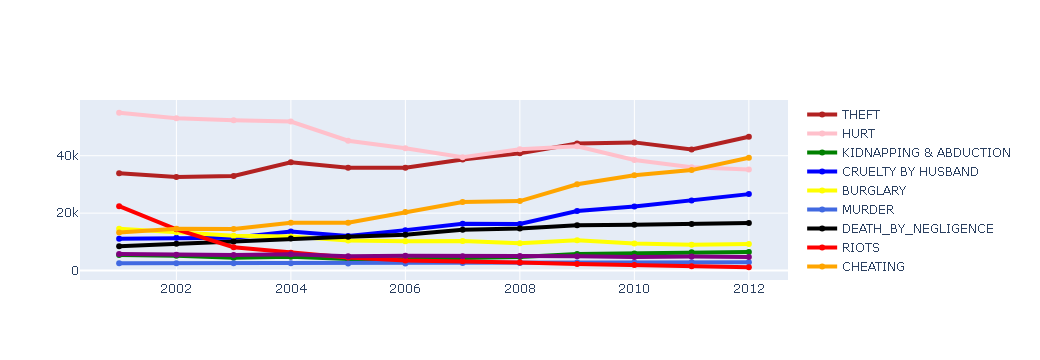

In [133]:
fig = go.Figure()
fig.add_trace(go.Scatter(x= DIST_RAJ["YEAR"], y= DIST_RAJ['THEFT'],
                    name = "THEFT",line=dict(color='firebrick', width=4)))
fig.add_trace(go.Scatter(x= DIST_RAJ["YEAR"], y= DIST_RAJ['HURT/GREVIOUS HURT'],
                    name='HURT',line=dict(color='pink', width=4)))
fig.add_trace(go.Scatter(x= DIST_RAJ["YEAR"], y= DIST_RAJ['KIDNAPPING & ABDUCTION'],
                    name='KIDNAPPING & ABDUCTION',line=dict(color='green', width=4)))
fig.add_trace(go.Scatter(x= DIST_RAJ["YEAR"], y= DIST_RAJ["CRUELTY BY HUSBAND OR HIS RELATIVES"],
                    name='CRUELTY BY HUSBAND',line=dict(color='blue', width=4)))
fig.add_trace(go.Scatter(x= DIST_RAJ["YEAR"], y= DIST_RAJ['BURGLARY'],
                    name='BURGLARY',line=dict(color='yellow', width=4)))
fig.add_trace(go.Scatter(x= DIST_RAJ["YEAR"], y= DIST_RAJ['MURDER'],
                    name='MURDER',line=dict(color='royalblue', width=4)))
fig.add_trace(go.Scatter(x= DIST_RAJ["YEAR"], y= DIST_RAJ['CAUSING DEATH BY NEGLIGENCE'],
                    name='DEATH_BY_NEGLIGENCE',line=dict(color='black', width=4)))
fig.add_trace(go.Scatter(x= DIST_RAJ["YEAR"], y= DIST_RAJ['RIOTS'],
                    name='RIOTS',line=dict(color='red', width=4)))
fig.add_trace(go.Scatter(x= DIST_RAJ["YEAR"], y= DIST_RAJ['CHEATING'],
                    name='CHEATING',line=dict(color='orange', width=4)))
fig.add_trace(go.Scatter(x= DIST_RAJ["YEAR"], y= DIST_RAJ['ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY'],
                    name='ASSAULT_WOMEN_MODESTY',line=dict(color='purple', width=4)))
fig.update_layout(uniformtext_minsize= 20)
fig.show()

In [134]:
crimes_RAJ_df = crimes_RAJ[crimes_RAJ.DISTRICT!="TOTAL"]
crimes_RAJ_df = crimes_RAJ_df.groupby('DISTRICT').agg({"THEFT":sum, 'HURT/GREVIOUS HURT':sum, 'CHEATING':sum}).reset_index()

In [135]:
RAJ_crimes = crimes_RAJ_df[(crimes_RAJ_df.THEFT>10000) & (crimes_RAJ_df['HURT/GREVIOUS HURT']>5000) & (crimes_RAJ_df['CHEATING']>2000)].reset_index()


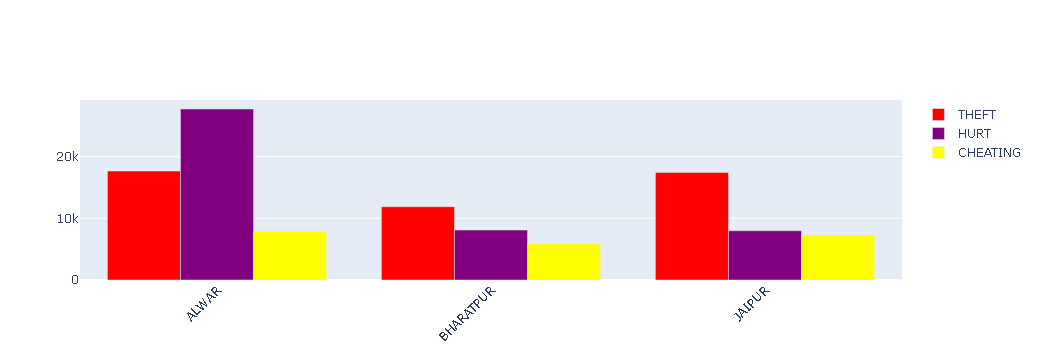

In [136]:
fig = go.Figure()
fig.add_trace(go.Bar(
    x=RAJ_crimes["DISTRICT"],
    y=RAJ_crimes["THEFT"],
    name='THEFT',
    marker_color='red'
))
fig.add_trace(go.Bar(
    x=RAJ_crimes["DISTRICT"],
    y=RAJ_crimes["HURT/GREVIOUS HURT"],
    name='HURT',
    marker_color='Purple'
))
fig.add_trace(go.Bar(
    x=RAJ_crimes["DISTRICT"],
    y=RAJ_crimes["CHEATING"],
    name='CHEATING',
    marker_color='yellow'
))
fig.update_layout(barmode='group', xaxis_tickangle=-45)
fig.show()

In [137]:
crimes_RAJ_clus = crimes_RAJ.copy()
crimes_RAJ_clus.drop(["STATE/UT", 'TOTAL IPC CRIMES', 'YEAR', 'ATTEMPT TO MURDER',
       'CULPABLE HOMICIDE NOT AMOUNTING TO MURDER', 'RAPE', 'CUSTODIAL RAPE',
       'OTHER RAPE',  'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
       'KIDNAPPING AND ABDUCTION OF OTHERS', 'DACOITY',
       'PREPARATION AND ASSEMBLY FOR DACOITY', 'ROBBERY', 'THEFT',
       'AUTO THEFT', 'OTHER THEFT', 'COUNTERFIETING', 'ARSON', 'DOWRY DEATHS', 'INSULT TO MODESTY OF WOMEN', 'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES'], axis=1 ,inplace = True)

In [138]:
crimes_RAJ_main = crimes_RAJ_clus[crimes_RAJ_clus.DISTRICT!="TOTAL"]
crimes_KMe_RAJ = crimes_RAJ_main.groupby("DISTRICT").agg({'HURT/GREVIOUS HURT':sum,'KIDNAPPING & ABDUCTION':sum,'CRUELTY BY HUSBAND OR HIS RELATIVES':sum, 
                                                       'BURGLARY':sum, 'MURDER':sum,'CAUSING DEATH BY NEGLIGENCE':sum,
                                                      'CHEATING':sum, 'RIOTS':sum, 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY':sum, 'OTHER IPC CRIMES':sum}).reset_index()


In [139]:
scaled = StandardScaler()
scaled_RAJ = scaled.fit_transform(crimes_KMe_RAJ[['HURT/GREVIOUS HURT','KIDNAPPING & ABDUCTION','CRUELTY BY HUSBAND OR HIS RELATIVES', 
                                                       'BURGLARY', 'MURDER','CAUSING DEATH BY NEGLIGENCE',
                                                      'CHEATING', 'RIOTS', 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY', 'OTHER IPC CRIMES']])

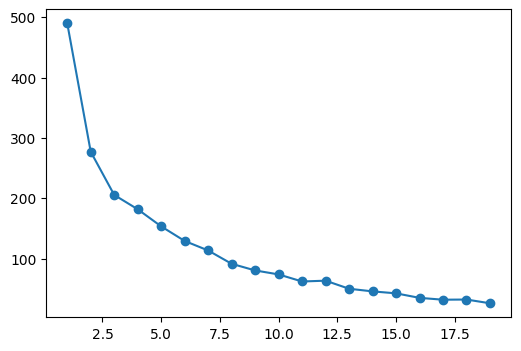

In [140]:
new_RAJ = range(1,20)
rate_RAJ = []
for i in new_RAJ:
    clustering = KMeans(i)
    clustering.fit(scaled_RAJ)
    rate_RAJ.append(clustering.inertia_)
    
plt.figure(figsize=(6,4))
plt.plot(new_RAJ, rate_RAJ, marker="o")

In [141]:
K=3
cluster_raj = KMeans(3, random_state = 42)
cluster_raj.fit(scaled_RAJ)
crimes_KMe_RAJ['Cluster_id'] = cluster_raj.labels_


In [142]:
crimes_KMe_RAJ[crimes_KMe_RAJ.Cluster_id==0]

,DISTRICT,HURT/GREVIOUS HURT,KIDNAPPING & ABDUCTION,CRUELTY BY HUSBAND OR HIS RELATIVES,BURGLARY,MURDER,CAUSING DEATH BY NEGLIGENCE,CHEATING,RIOTS,ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY,OTHER IPC CRIMES,Cluster_id
14,G.R.P.,36,40,1,20,44,23,53,57,131,3017,0
15,G.R.P. AJMER,0,1,0,2,6,1,3,2,1,203,0
16,G.R.P. JODHPUR,1,0,0,0,2,0,0,3,1,44,0
17,G.R.P.AJMER,9,14,0,1,10,3,10,6,22,236,0
18,G.R.P.JODHPUR,1,3,0,1,6,5,0,2,9,85,0
26,JAIPUR WEST,467,157,465,582,53,549,1804,14,43,3592,0
27,JAISALMER,1420,113,245,646,81,537,680,198,202,5450,0
32,JODHPUR CITY,3366,314,1475,1079,117,904,3187,72,238,5450,0
33,JODHPUR EAST,417,15,296,50,12,114,447,0,16,459,0
34,JODHPUR RURAL,6650,231,692,655,177,1568,1275,61,281,5583,0


In [143]:
crimes_KMe_RAJ[crimes_KMe_RAJ.Cluster_id==1]

,DISTRICT,HURT/GREVIOUS HURT,KIDNAPPING & ABDUCTION,CRUELTY BY HUSBAND OR HIS RELATIVES,BURGLARY,MURDER,CAUSING DEATH BY NEGLIGENCE,CHEATING,RIOTS,ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY,OTHER IPC CRIMES,Cluster_id
2,BANSWARA,11890,699,1477,880,403,1224,912,1701,866,9233,1
3,BARAN,4302,810,2610,1368,403,1111,2076,390,1864,18468,1
4,BARMER,7119,329,1390,1197,256,1688,2252,212,914,14585,1
7,BIKANER,6008,395,3447,1601,478,2275,4237,129,691,19958,1
8,BUNDI,9853,1057,2819,1424,273,1399,1976,708,1456,15014,1
10,CHURU,7861,388,2840,1155,339,1530,3335,505,418,11938,1
11,DAUSA,1099,758,1363,1071,355,2443,2697,1319,273,30684,1
12,DHOLPUR,15705,691,1653,677,529,1205,1499,1188,325,10554,1
13,DUNGARPUR,1858,565,935,607,298,1249,544,1147,643,12698,1
20,HANUMANGARH,5339,469,3529,1286,611,1393,5121,221,888,19428,1


In [144]:
crimes_KMe_RAJ[crimes_KMe_RAJ.Cluster_id==2]

,DISTRICT,HURT/GREVIOUS HURT,KIDNAPPING & ABDUCTION,CRUELTY BY HUSBAND OR HIS RELATIVES,BURGLARY,MURDER,CAUSING DEATH BY NEGLIGENCE,CHEATING,RIOTS,ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY,OTHER IPC CRIMES,Cluster_id
0,AJMER,4138,1256,5489,3507,538,4889,7106,589,1023,37919,2
1,ALWAR,27728,1598,4781,2563,1019,4610,7895,957,1479,27345,2
5,BHARATPUR,8099,1646,4103,1002,983,2549,5860,506,618,50404,2
6,BHILWARA,1982,1506,4770,3119,398,3095,4844,1192,1176,31450,2
9,CHITTORGARH,19974,1709,5473,2857,512,2393,3523,1836,1264,18445,2
19,GANGANAGAR,12004,792,6060,2379,691,1868,7757,114,844,22923,2
21,JAIPUR,7996,1167,2526,4822,439,4192,7308,8649,1006,41008,2
41,PALI,531,1040,3612,2389,462,3030,3620,440,1353,37123,2
48,UDAIPUR,18161,1787,3234,3278,825,3986,6490,2983,1529,30212,2


In [148]:
#Crimes in KARNATAKA
crimes_KAR = df[df['STATE/UT']=='KARNATAKA']
crimes_KAR.shape
DIST_KAR = crimes_KAR[crimes_KAR.DISTRICT=='TOTAL']
DIST_KAR = crimes_KAR.groupby(['YEAR']).agg({'THEFT':sum,'HURT/GREVIOUS HURT':sum,'KIDNAPPING & ABDUCTION':sum,'CRUELTY BY HUSBAND OR HIS RELATIVES':sum, 
                                                       'BURGLARY':sum, 'MURDER':sum,'CAUSING DEATH BY NEGLIGENCE':sum,
                                                      'CHEATING':sum, 'RIOTS':sum, 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY':sum}).reset_index()

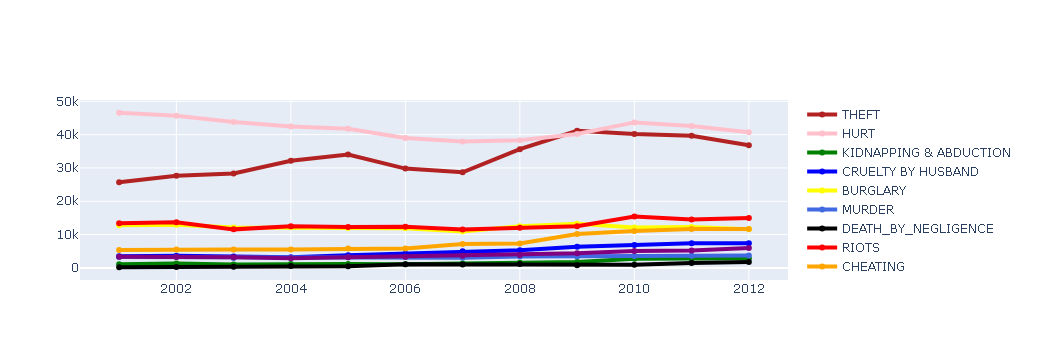

In [149]:
fig = go.Figure()
fig.add_trace(go.Scatter(x= DIST_KAR["YEAR"], y= DIST_KAR['THEFT'],
                    name = "THEFT",line=dict(color='firebrick', width=4)))
fig.add_trace(go.Scatter(x= DIST_KAR["YEAR"], y= DIST_KAR['HURT/GREVIOUS HURT'],
                    name='HURT',line=dict(color='pink', width=4)))
fig.add_trace(go.Scatter(x= DIST_KAR["YEAR"], y= DIST_KAR['KIDNAPPING & ABDUCTION'],
                    name='KIDNAPPING & ABDUCTION',line=dict(color='green', width=4)))
fig.add_trace(go.Scatter(x= DIST_KAR["YEAR"], y= DIST_KAR["CRUELTY BY HUSBAND OR HIS RELATIVES"],
                    name='CRUELTY BY HUSBAND',line=dict(color='blue', width=4)))
fig.add_trace(go.Scatter(x= DIST_KAR["YEAR"], y= DIST_KAR['BURGLARY'],
                    name='BURGLARY',line=dict(color='yellow', width=4)))
fig.add_trace(go.Scatter(x= DIST_KAR["YEAR"], y= DIST_KAR['MURDER'],
                    name='MURDER',line=dict(color='royalblue', width=4)))
fig.add_trace(go.Scatter(x= DIST_KAR["YEAR"], y= DIST_KAR['CAUSING DEATH BY NEGLIGENCE'],
                    name='DEATH_BY_NEGLIGENCE',line=dict(color='black', width=4)))
fig.add_trace(go.Scatter(x= DIST_KAR["YEAR"], y= DIST_KAR['RIOTS'],
                    name='RIOTS',line=dict(color='red', width=4)))
fig.add_trace(go.Scatter(x= DIST_KAR["YEAR"], y= DIST_KAR['CHEATING'],
                    name='CHEATING',line=dict(color='orange', width=4)))
fig.add_trace(go.Scatter(x= DIST_KAR["YEAR"], y= DIST_KAR['ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY'],
                    name='ASSUALT_WOMEN_MODESTY',line=dict(color='purple', width=4)))
fig.update_layout(uniformtext_minsize= 20)
fig.show()

In [150]:
crimes_KAR_df = crimes_KAR[crimes_KAR.DISTRICT!="TOTAL"]
crimes_KAR_df = crimes_KAR_df.groupby('DISTRICT').agg({"THEFT":sum, 'HURT/GREVIOUS HURT':sum}).reset_index()
crimes_KAR_df

,DISTRICT,THEFT,HURT/GREVIOUS HURT
0,BAGALKOT,1561,3398
1,BANGALORE COMMR.,105434,37973
2,BANGALORE RURAL,9055,10804
3,BELGAUM,5130,11119
4,BELLARY,3519,6220
5,BIDAR,2313,11718
6,BIJAPUR,1739,7409
7,CBPURA,1329,1856
8,CHAMARAJNAGAR,1495,5348
9,CHICKMAGALUR,2507,9579


In [157]:
KAR_crimes = crimes_KAR_df[(crimes_KAR_df['THEFT']>1000) & (crimes_KAR_df['HURT/GREVIOUS HURT']>5000)].reset_index()


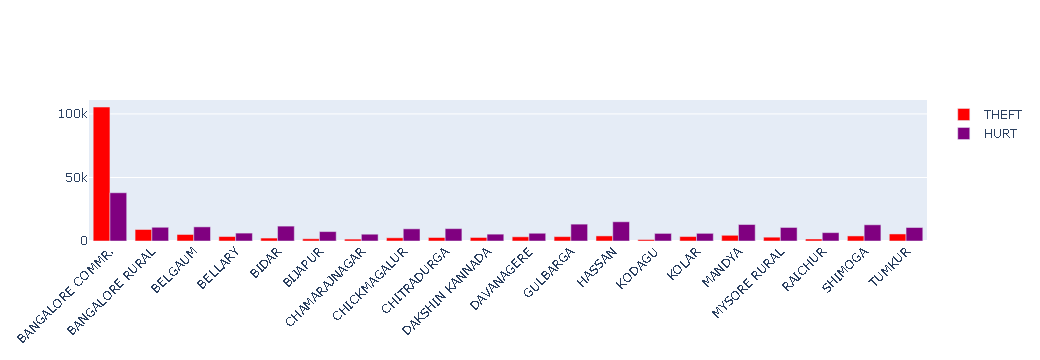

In [158]:
fig = go.Figure()
fig.add_trace(go.Bar(
    x=KAR_crimes["DISTRICT"],
    y=KAR_crimes["THEFT"],
    name='THEFT',
    marker_color='red'
))
fig.add_trace(go.Bar(
    x=KAR_crimes["DISTRICT"],
    y=KAR_crimes["HURT/GREVIOUS HURT"],
    name='HURT',
    marker_color='Purple'
))
fig.update_layout(barmode='group', xaxis_tickangle=-45)
fig.show()

In [160]:
crimes_KAR_clus = crimes_KAR.copy()
crimes_KAR_clus.drop(["STATE/UT", 'TOTAL IPC CRIMES', 'YEAR', 'ATTEMPT TO MURDER',
       'CULPABLE HOMICIDE NOT AMOUNTING TO MURDER', 'RAPE', 'CUSTODIAL RAPE',
       'OTHER RAPE',  'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
       'KIDNAPPING AND ABDUCTION OF OTHERS', 'DACOITY',
       'PREPARATION AND ASSEMBLY FOR DACOITY', 'ROBBERY', 'THEFT',
       'AUTO THEFT', 'OTHER THEFT', 'COUNTERFIETING', 'ARSON', 'DOWRY DEATHS', 'INSULT TO MODESTY OF WOMEN', 'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES'], axis=1 ,inplace = True)


In [163]:
crimes_KAR_main = crimes_KAR_clus[crimes_KAR_clus.DISTRICT!="TOTAL"]
crimes_KMe_kar = crimes_KAR_main.groupby("DISTRICT").agg({'HURT/GREVIOUS HURT':sum,'KIDNAPPING & ABDUCTION':sum,'CRUELTY BY HUSBAND OR HIS RELATIVES':sum, 
                                                       'BURGLARY':sum, 'MURDER':sum,'CAUSING DEATH BY NEGLIGENCE':sum,
                                                      'CHEATING':sum, 'RIOTS':sum, 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY':sum, 'OTHER IPC CRIMES':sum}).reset_index()

In [166]:
scaled = StandardScaler()
scaled_Kar = scaled.fit_transform(crimes_KMe_kar[['HURT/GREVIOUS HURT','KIDNAPPING & ABDUCTION','CRUELTY BY HUSBAND OR HIS RELATIVES', 
                                                       'BURGLARY', 'MURDER','CAUSING DEATH BY NEGLIGENCE',
                                                      'CHEATING', 'RIOTS', 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY', 'OTHER IPC CRIMES']])

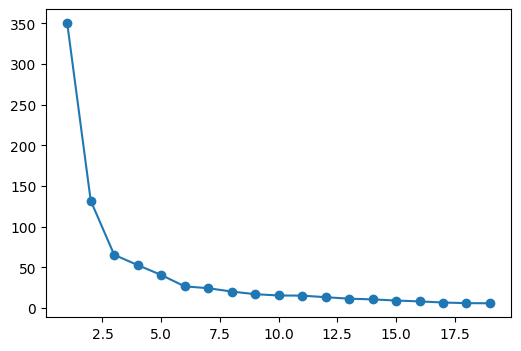

In [167]:
new_kar = range(1,20)
rate_kar = []
for i in new_kar:
    clustering = KMeans(i)
    clustering.fit(scaled_Kar)
    rate_kar.append(clustering.inertia_)
    
plt.figure(figsize=(6,4))
plt.plot(new_kar, rate_kar, marker="o")

In [168]:
K=3
cluster_kar = KMeans(3, random_state = 42)
cluster_kar.fit(scaled_Kar)
crimes_KMe_kar['Cluster_id'] = cluster_kar.labels_

In [169]:
crimes_KMe_kar[crimes_KMe_kar.Cluster_id==0]

,DISTRICT,HURT/GREVIOUS HURT,KIDNAPPING & ABDUCTION,CRUELTY BY HUSBAND OR HIS RELATIVES,BURGLARY,MURDER,CAUSING DEATH BY NEGLIGENCE,CHEATING,RIOTS,ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY,OTHER IPC CRIMES,Cluster_id
0,BAGALKOT,3398,219,712,983,537,0,487,2162,604,13059,0
7,CBPURA,1856,119,229,620,228,8,317,1087,225,4791,0
8,CHAMARAJNAGAR,5348,82,387,810,307,0,197,1330,527,7426,0
9,CHICKMAGALUR,9579,178,1035,1832,398,50,356,1747,692,15158,0
11,DAKSHIN KANNADA,5393,132,489,2343,386,116,910,2468,479,25409,0
13,DHARWAD COMMR.,2179,209,426,1596,226,71,1334,1145,135,11573,0
14,DHARWAD RURAL,1762,87,198,371,323,0,184,1194,250,7533,0
15,GADAG,1923,83,313,627,246,758,258,1298,357,5232,0
18,HAVERI,3363,166,445,905,283,927,388,2787,540,13328,0
19,K.G.F.,2930,104,246,780,167,184,221,730,181,3558,0


In [170]:
crimes_KMe_kar[crimes_KMe_kar.Cluster_id==1]

,DISTRICT,HURT/GREVIOUS HURT,KIDNAPPING & ABDUCTION,CRUELTY BY HUSBAND OR HIS RELATIVES,BURGLARY,MURDER,CAUSING DEATH BY NEGLIGENCE,CHEATING,RIOTS,ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY,OTHER IPC CRIMES,Cluster_id
2,BANGALORE RURAL,10804,430,1149,4268,1579,0,1256,4589,1041,40266,1
3,BELGAUM,11119,513,2342,2948,1402,382,2430,4830,1576,38161,1
4,BELLARY,6220,233,803,1811,646,158,720,2680,729,22873,1
5,BIDAR,11718,253,832,1802,472,55,476,1934,712,23267,1
6,BIJAPUR,7409,338,1392,1518,736,0,699,3567,883,18172,1
10,CHITRADURGA,9739,226,648,1454,439,1,444,3401,954,23788,1
12,DAVANAGERE,6103,221,1092,1949,422,38,647,2944,873,17337,1
16,GULBARGA,13278,588,1534,2558,1182,184,929,5328,1264,23604,1
17,HASSAN,15135,266,1213,2747,755,0,747,2328,965,27310,1
23,MANDYA,12973,252,1354,2710,756,0,551,3355,915,27855,1


In [171]:
crimes_KMe_kar[crimes_KMe_kar.Cluster_id==2]

,DISTRICT,HURT/GREVIOUS HURT,KIDNAPPING & ABDUCTION,CRUELTY BY HUSBAND OR HIS RELATIVES,BURGLARY,MURDER,CAUSING DEATH BY NEGLIGENCE,CHEATING,RIOTS,ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY,OTHER IPC CRIMES,Cluster_id
1,BANGALORE COMMR.,37973,3014,3832,19968,2831,1182,26401,4665,2630,124176,2
